# AI3 Machine Project: LLM Chatbot
**Group Name:** KitKat

**Members:**
- PRINCE JEFFREY VILLAMIL
- LEILA JANINE VILLEGAS
- LIANDRO REFULLE

## Section 1. Introduction to the Problem/Task
This project implements a Retrieval-Augmented Generation (RAG) conversational chatbot designed to act as an intelligent assistant for the Department of Foreign Affairs (DFA). Specifically, it focuses on the Home Office Operation Manual for the Authentication Division, Office of Consular Affairs. The goal is to provide personnel and users with immediate, accurate, and grounded answers regarding consular procedures, expedited authentication fees, and processing workflows. Building this system reduces manual search time through dense bureaucratic manuals and ensures policy compliance.

## Section 2. Dataset Description
* **Knowledge Source:** PDF documents containing the DFA Operations Manual (Authentication Division).
* **Collection Method:** Direct upload of the official manual documents.
* **Dataset Structure:** Unstructured text extracted from PDF pages.
* **Preprocessing:** Text is cleaned using regular expressions to remove excessive whitespace. It is then split using a sliding window chunking strategy (900 characters per chunk with a 150-character overlap) to preserve context without exceeding token limits.
* **Embedding Process:** Chunks are vectorized using `sentence-transformers/all-MiniLM-L6-v2` (384 dimensions) and indexed using FAISS for efficient cosine similarity search.

## Section 3. Requirements

In [1]:
!pip -q install pypdf sentence-transformers faiss-cpu transformers accelerate ipywidgets
# # !pip install ragas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.4/331.4 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 43.9 MB/s eta 0:00:00


## Section 4. System Architecture
Our system utilizes a local RAG pipeline:
1. **Document Insertion:** PDFs are loaded and chunked.
2. **Vector Store:** Chunks are embedded using `all-MiniLM-L6-v2` and stored in a FAISS FlatIP index.
3. **Retriever:** User queries are embedded, and the top-k most similar chunks are retrieved.
4. **Generator:** The retrieved context and the user query are injected into a strict prompt template and passed to `microsoft/Phi-3-mini-4k-instruct` to generate a concise, grounded answer. Guardrails (similarity score thresholds) prevent hallucinations on out-of-domain questions.

In [17]:
import pandas as pd
import time
import re
import csv
from datetime import datetime

In [3]:
from google.colab import files
uploaded = files.upload()  # select one or more PDFs
pdf_paths = list(uploaded.keys())
pdf_paths

Saving DFA_Operations_Manual-1.pdf to DFA_Operations_Manual-1.pdf


['DFA_Operations_Manual-1.pdf']

###CONFIG Settings

In [4]:
# CONFIG

# Chunking Settings
CHUNK_SIZE_VAR = 600 # 900 - initial
CHUNK_OVERLAP_VAR = 100 # 150 - initial

# Retrieval Settings
TOP_K_VAR = 3 #5 initial

# Answer
MIN_SCORE = 0.45  # Guardrail for out-of-document questions
#
PROMPT_VAR = f"""You are a strict document-based question-answering system.

You must answer using ONLY explicit statements found in the context.
Do NOT infer.
Do NOT paraphrase missing information.
Do NOT combine partial facts.
If the answer is not explicitly stated word-for-word in the context,
respond exactly:
"I don't know based on the provided PDFs."
"""


In [5]:
from pypdf import PdfReader

def extract_pdf_text(path: str) -> list[dict]:
    reader = PdfReader(path)
    pages = []
    for i, page in enumerate(reader.pages):
        text = page.extract_text() or ""
        pages.append({"source": path, "page": i + 1, "text": text})
    return pages

docs_pages = []
for p in pdf_paths:
    docs_pages.extend(extract_pdf_text(p))

len(docs_pages), docs_pages[0].keys()


(80, dict_keys(['source', 'page', 'text']))

###Chunking

In [ ]:
# import re

# def clean_text(t: str) -> str:
#     t = re.sub(r"\s+", " ", t).strip()
#     return t

# def chunk_text(text: str, chunk_size=CHUNK_SIZE_VAR, overlap=CHUNK_OVERLAP_VAR):
#     text = clean_text(text)
#     chunks = []
#     start = 0
#     while start < len(text):
#         end = min(len(text), start + chunk_size)
#         chunks.append(text[start:end])
#         start = end - overlap
#         if start < 0: start = 0
#         if end == len(text): break
#     return chunks

# chunks = []
# for p in docs_pages:
#     for c in chunk_text(p["text"]):
#         if c.strip():
#             chunks.append({
#                 "source": p["source"],
#                 "page": p["page"],
#                 "text": c
#             })

# len(chunks), chunks[0]["text"][:120]


(267,
 'DEPARTMENT OF FOREIGN AFFAIRS HOME OFFICE OPERATIONS MANUAL With focus on the Authentication Division Office of Consular')

#### OLD Chunking Log Summary

| Metric | Value |
|------|------|
| Chunk Log File | chunk_log_20260308_132545.csv |
| Total Chunks Logged | 267 |
| Total Chunks | 267 |
| Average Chunk Size | 529 chars |
| Minimum Chunk Size | 29 chars |
| Maximum Chunk Size | 600 chars |
| Chunks with Overlap Prefix | 154 |

---

### Sample Chunks

| Chunk ID | Sample Text |
|---|---|
| 1 | DEPARTMENT OF FOREIGN AFFAIRS HOME OFFICE OPERATIONS MANUAL With focus on the Authentication Division Office of Consular Affairs 3 November 2015 |
| 2 | DEPARTMENT OF FOREIGN Page No.: Page 1 of 1 AFFAIRS HOME OFFICE OPERATIONS MANUAL Revision No.: 0o DFA-OM TABLE OF CONTENTS Effectivity: 3 November 2015 INTRODUCTION ON THE DEPARTMENT ORGANIZATION AND RESPONSIBILITIES IN THE HOME OFFICE LINE OF AUTHORITY AND OPERATIONAL CONTROLS INTRODUCTION TO THE MANUAL OPERATIONS MANUAL OF THE AUTHENTICATION DIVISION APPENDIX |

---

### Preview

| Description | Text |
|---|---|
| Sample Preview | DEPARTMENT OF FOREIGN AFFAIRS HOME OFFICE OPERATIONS MANUAL With focus on the Authentication Division Office of Consular |

✓ Chunk log saved: chunk_log_20260308_132545.csv
  Total chunks logged: 267

── Chunking Summary ──────────────────────────────────────────
  Total chunks:               267
  Avg chunk size:             529 chars
  Min / Max chunk size:       29 / 600 chars
  Chunks with overlap prefix: 154
──────────────────────────────────────────────────────────────

Sample chunk 1:
DEPARTMENT OF FOREIGN AFFAIRS HOME OFFICE OPERATIONS MANUAL With focus on the Authentication Division Office of Consular Affairs 3 November 2015

Sample chunk 2:
DEPARTMENT OF FOREIGN Page No.: Page 1 of 1 AFFAIRS HOME OFFICE OPERATIONS MANUAL Revision No.: 0o DFA-OM TABLE OF CONTENTS Effectivity: 3November 2015 \'/B INTRODUCTION ON THE DEPARTMENT ORGANIZATION AND RESPONSIBILITIES IN THE HOME OFFICE LINE OF AUTHORITY AND OPERATIONAL CONTROLS INTRODUCTION TO THE MANUAL OPERATIONS MANUAL OF THE AUTHENTICATION DIVISION APPENDIX

Total chunks: 267
Sample preview: DEPARTMENT OF FOREIGN AFFAIRS HOME OFFICE OPERATIONS MANUAL W

| Aspect | Original Strategy | Fixed Strategy | What This Means |
|--------|------------------|----------------|-----------------|
| Split Method | Hard cut every 600 chars | Splits on `. ! ?` sentence boundaries | Original splits strictly by character count, even mid-sentence. Fixed version respects sentence endings. |
| Mid-Sentence Cuts | Happens constantly | Avoided | Original often breaks sentences unnaturally. Fixed keeps sentences intact whenever possible. |
| Overlap | Character slice of previous chunk | Tail of last full sentence chunk | Original overlaps arbitrary characters. Fixed overlaps complete sentence endings for better context continuity. |
| Long Sentence Fallback | N/A | Falls back to char split gracefully | If a sentence is longer than the limit, fixed version safely splits by characters instead of failing. |
| Empty Text Guard | None | Handled | Fixed version checks for empty input to prevent errors or crashes. |

In [23]:
import re

def clean_text(t: str) -> str:
    t = re.sub(r"\s+", " ", t).strip()
    return t

def chunk_text(text: str, chunk_size=CHUNK_SIZE_VAR, overlap=CHUNK_OVERLAP_VAR):
    text = clean_text(text)
    if not text:
        return []

    # Split into sentences using punctuation boundaries
    # Splits on:  .  !  ?  followed by whitespace (keeps cross-language sentences)
    raw_sentences = re.split(r'(?<=[.!?])\s+', text)
    sentences = [s.strip() for s in raw_sentences if s.strip()]

    if not sentences:
        return []

    chunks = []
    current_chunk = ""

    for sentence in sentences:

        # If adding this sentence stays within limit, append it
        if len(current_chunk) + len(sentence) + 1 <= chunk_size:
            current_chunk = (current_chunk + " " + sentence).strip()

        else:
            # if Current chunk is full should save it
            if current_chunk:
                chunks.append(current_chunk)

            # Handles sentences longer than chunk_size
            # (so a very long run-on sentence — fall back to character split)
            if len(sentence) > chunk_size:
                start = 0
                while start < len(sentence):
                    end = min(len(sentence), start + chunk_size)
                    chunks.append(sentence[start:end])
                    start = end - overlap
                    if start < 0:
                        start = 0
                    if end == len(sentence):
                        break
                current_chunk = ""

            else:
                # Start new chunk with overlap from previous chunk
                # Take the tail of the last saved chunk as context carry-over
                if chunks:
                    overlap_text = chunks[-1][-overlap:].strip()
                    current_chunk = (overlap_text + " " + sentence).strip()
                else:
                    current_chunk = sentence

    if current_chunk:
        chunks.append(current_chunk)

    return chunks


chunks = []
for p in docs_pages:
    for c in chunk_text(p["text"]):
        if c.strip():
            chunks.append({
                "source": p["source"],
                "page":   p["page"],
                "text":   c
            })

# check
print(f"Total chunks: {len(chunks)}")
print(f"\nSample chunk 1:\n{chunks[0]['text']}\n")
print(f"Sample chunk 2:\n{chunks[1]['text']}\n")

# Finl check on no chunk ends mid-sentence (should end with . ! or ?)
bad_endings = [c for c in chunks if c["text"] and c["text"][-1] not in ".!?)\"'"]
print(f"Chunks not ending on sentence boundary: {len(bad_endings)} / {len(chunks)}")
if bad_endings:
    print("Example bad chunk tail:", bad_endings[0]["text"][-80:])

Total chunks: 312

Sample chunk 1:
DEPARTMENT OF FOREIGN AFFAIRS HOME OFFICE OPERATIONS MANUAL With focus on the Authentication Division Office of Consular Affairs 3 November 2015

Sample chunk 2:
DEPARTMENT OF FOREIGN Page No.: Page 1 of 1 AFFAIRS HOME OFFICE OPERATIONS MANUAL Revision No.: 0o DFA-OM TABLE OF CONTENTS Effectivity: 3November 2015 \'/B INTRODUCTION ON THE DEPARTMENT ORGANIZATION AND RESPONSIBILITIES IN THE HOME OFFICE LINE OF AUTHORITY AND OPERATIONAL CONTROLS INTRODUCTION TO THE MANUAL OPERATIONS MANUAL OF THE AUTHENTICATION DIVISION APPENDIX

Chunks not ending on sentence boundary: 99 / 312
Example bad chunk tail:  focus on the Authentication Division Office of Consular Affairs 3 November 2015


#### UPDATED Chunking Log Summary

| Metric | Value |
|------|------|
| Chunk Log File | chunk_log_20260308_132337.csv |
| Total Chunks Logged | 312 |
| Total Chunks | 312 |
| Average Chunk Size | 457 chars |
| Minimum Chunk Size | 9 chars |
| Maximum Chunk Size | 692 chars |
| Chunks with Overlap Prefix | 196 |
| Fallback (Hard) Splits | 99 |
| Clean Boundary Endings | 213 / 312 |

---

### Sample Chunks

| Chunk ID | Sample Text |
|---|---|
| 1 | DEPARTMENT OF FOREIGN AFFAIRS HOME OFFICE OPERATIONS MANUAL With focus on the Authentication Division Office of Consular Affairs 3 November 2015 |
| 2 | DEPARTMENT OF FOREIGN Page No.: Page 1 of 1 AFFAIRS HOME OFFICE OPERATIONS MANUAL Revision No.: 0o DFA-OM TABLE OF CONTENTS Effectivity: 3 November 2015 INTRODUCTION ON THE DEPARTMENT ORGANIZATION AND RESPONSIBILITIES IN THE HOME OFFICE LINE OF AUTHORITY AND OPERATIONAL CONTROLS INTRODUCTION TO THE MANUAL OPERATIONS MANUAL OF THE AUTHENTICATION DIVISION APPENDIX |

---

### Chunk Boundary Quality

| Metric | Value |
|---|---|
| Chunks Not Ending on Sentence Boundary | 99 / 312 |
| Example Bad Chunk Tail | focus on the Authentication Division Office of Consular Affairs 3 November 2015 |

✓ Chunk log saved: chunk_log_20260308_132337.csv
  Total chunks logged: 312

── Chunking Summary ──────────────────────────────────────────
  Total chunks:               312
  Avg chunk size:             457 chars
  Min / Max chunk size:       9 / 692 chars
  Chunks with overlap prefix: 196
  Fallback (hard) splits:     99
  Clean boundary endings:     213 / 312
──────────────────────────────────────────────────────────────

Sample chunk 1:
DEPARTMENT OF FOREIGN AFFAIRS HOME OFFICE OPERATIONS MANUAL With focus on the Authentication Division Office of Consular Affairs 3 November 2015

Sample chunk 2:
DEPARTMENT OF FOREIGN Page No.: Page 1 of 1 AFFAIRS HOME OFFICE OPERATIONS MANUAL Revision No.: 0o DFA-OM TABLE OF CONTENTS Effectivity: 3November 2015 \'/B INTRODUCTION ON THE DEPARTMENT ORGANIZATION AND RESPONSIBILITIES IN THE HOME OFFICE LINE OF AUTHORITY AND OPERATIONAL CONTROLS INTRODUCTION TO THE MANUAL OPERATIONS MANUAL OF THE AUTHENTICATION DIVISION APPENDIX

Chunks not ending on se

###Sentence Transformer

In [7]:
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer, util

# embed_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
embed_model = SentenceTransformer("BAAI/bge-large-en-v1.5")
# all-MiniLM-L6-v2: This is frequently cited as the best choice for running local RAG solutions with Phi-3, often used in conjunction with tools like llama.cpp for its speed and low memory footprint, while maintaining good embedding quality.
# bge-micro-v2 or bge-m3: These models are recommended for retrieval embeddings to be used specifically with Phi-3 in local RAG scenarios.
# snowflake-arctic-embed: A highly accurate embedding model that performs well for semantic search.

texts = [c["text"] for c in chunks]
emb = embed_model.encode(texts, batch_size=32, show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=True)

dim = emb.shape[1]
index = faiss.IndexFlatIP(dim)  # cosine similarity since normalized
index.add(emb)

print("Embeddings:", emb.shape, "Index size:", index.ntotal)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Embeddings: (312, 1024) Index size: 312


###Model - "microsoft/Phi-3-mini-4k-instruct"

In [8]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch

model_name = "microsoft/Phi-3-mini-4k-instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
)

gen = pipeline("text-generation", model=model, tokenizer=tokenizer)


config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

In [ ]:
# Not really the issue/didnt show any big step
# from sentence_transformers import CrossEncoder
# reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

###Retrive

In [9]:
def retrieve(query: str, k=TOP_K_VAR):
    q_emb = embed_model.encode([query], convert_to_numpy=True, normalize_embeddings=True)
    scores, idxs = index.search(q_emb, k)
    results = []
    for score, idx in zip(scores[0], idxs[0]):
        c = chunks[int(idx)]
        results.append({**c, "score": float(score)})
    return results

# 1. Embeds the query into a vector using embed_model.encode().
# 2. Searches the vector database (index.search) to find the top k most similar chunks of the documents.
# 3. Returns these chunks with their similarity scores.

In [ ]:
# ReRanking function
# After retrieving top 10, rerank with a cross-encoder and keep top 3.
# ===== Avg METRICS =====
# Avg Recall@K: 1.00
# Avg Precision@K: 0.50
# Avg Faithfulness: 0.63
# Avg Answer Relevancy: 0.76
# Not the issue, Avg scores got somewhat worst

# def retrieve(query, k=3):
#     q_emb = embed_model.encode([query], convert_to_numpy=True, normalize_embeddings=True)
#     scores, idxs = index.search(q_emb, 10)  # retrieve more first

#     candidates = [chunks[int(i)] for i in idxs[0]]

#     pairs = [[query, c["text"]] for c in candidates]
#     rerank_scores = reranker.predict(pairs)

#     ranked = sorted(
#         zip(candidates, rerank_scores),
#         key=lambda x: x[1],
#         reverse=True
#     )

#     return [
#         {**c, "score": float(s)}
#         for c, s in ranked[:k]
#     ]

###Answer

In [10]:
def answer(query: str, k=TOP_K_VAR, max_new_tokens=150):
    hits = retrieve(query, k=k)
    # Should watch for low min_score and reject if top chunk score is too low
    if not hits or hits[0]["score"] < MIN_SCORE:
        return "I don't know based on the provided PDFs. The requested information is not in the DFA manual.", hits

    context = "\n\n".join(
        [f"[{i+1}] (Source: {h['source']}, page {h['page']})\n{h['text']}"
         for i, h in enumerate(hits)]
    )

# - If the answer is not in the context, say exactly: "I don't know based on the provided PDFs."
# - STOP writing immediately after your answer.
# - Do NOT ask follow-up questions.
# - Do NOT continue any Q&A format.

    # prompt = f"""You are a question-answering system.
    # Answer ONLY the given question using ONLY the context below.
    # Do NOT generate additional questions.
    # Do NOT continue any Q&A format.
    # Return a concise answer (1-3 sentences max).
    # If the answer is not in the context, say exactly:
    # "I don't know based on the provided PDFs."
    # Context:
    # {context}

    # Question: {query}

    # Final Answer:"""
    prompt = f"""<|system|>
      You are a strict question-answering assistant for DFA documents.
      Answer using ONLY the context provided below.
      Rules:
      - Do NOT repeat the question.
      - If the answer is not in the context, say exactly: "I don't know based on the provided PDFs."
      <|end|>
      <|user|>
      Context:
      {context}

      Question: {query}<|end|>
      <|assistant|>"""

    out = gen(
        prompt,
        max_new_tokens=max_new_tokens,
        do_sample=False
    )[0]["generated_text"]

    # ── Extract only the assistant's reply ──
    if "<|assistant|>" in out:
        answer_text = out.split("<|assistant|>")[-1].strip()
    else:
        answer_text = out[len(prompt):].strip()

    # ── Post-processing: cut off any model drift ──
    for stop_token in ["<|end|>", "<|user|>", "<|system|>", "Question:", "Answer:"]:
        if stop_token in answer_text:
            answer_text = answer_text.split(stop_token)[0].strip()

    return answer_text, hits

# 1. Uses the retrieve function to get context, then uses the phi3 model to generate an answer.
#   2. Calls hits = retrieve(query, k=k) -> gets top k chunks.
#   3. Formats these chunks into a context string.
#   4. Feeds this context + the query into the (gen) LLM model to generate a concise answer.
#   5. Returns the model’s answer along with the retrieved hits.

| Score       | Meaning                     |
| ----------- | --------------------------- |
| 0.80 – 1.00 | Almost exact semantic match |
| 0.50 – 0.75 | Strong relevance            |
| 0.30 – 0.50 | Weak / borderline relevance |
| < 0.30      | Likely irrelevant           |



In [ ]:
print(model.config)

Phi3Config {
  "architectures": [
    "Phi3ForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "auto_map": {
    "AutoConfig": "configuration_phi3.Phi3Config",
    "AutoModelForCausalLM": "modeling_phi3.Phi3ForCausalLM"
  },
  "bos_token_id": 1,
  "dtype": "float16",
  "embd_pdrop": 0.0,
  "eos_token_id": 32000,
  "hidden_act": "silu",
  "hidden_size": 3072,
  "ignore_keys_at_rope_validation": null,
  "initializer_range": 0.02,
  "intermediate_size": 8192,
  "max_position_embeddings": 4096,
  "model_type": "phi3",
  "num_attention_heads": 32,
  "num_hidden_layers": 32,
  "num_key_value_heads": 32,
  "original_max_position_embeddings": 4096,
  "pad_token_id": 32000,
  "partial_rotary_factor": 1.0,
  "resid_pdrop": 0.0,
  "rms_norm_eps": 1e-05,
  "rope_parameters": {
    "partial_rotary_factor": 1.0,
    "rope_theta": 10000.0,
    "rope_type": "default"
  },
  "sliding_window": 2047,
  "tie_word_embeddings": false,
  "transformers_version": "5.0.0",
  "use_cache": 

###Single Chat Format Test

In [28]:
# CHAT Formatting | Optimized for "Phi-3-Mini"

import ipywidgets as widgets
from IPython.display import display

out = widgets.Output()
inp = widgets.Text(
    placeholder="Ask a question about the DFA manual...",
    description="You:",
    layout=widgets.Layout(width="80%")
)
btn = widgets.Button(description="Send", button_style='primary')

MIN_SCORE = 0.45  # Guardrail for out-of-document questions

def print_hits(hits):
    print(f"Total Chunks Retrieved: {len(hits)}\n" + "==================================================")
    for i, h in enumerate(hits, 1):
        print(f"[{i}] SCORE: {h['score']:.4f}")
        print(f"    SOURCE: {h['source']} (Page {h['page']})")
        print(f"    CONTENT: {h['text'][:400]}...") # Shows first 400 chars
        print("--------------------------------------------------")

def on_submit(_):
    q = inp.value.strip()
    if not q:
        return
    inp.value = ""

    # 1. Retrieve top chunks
    hits = retrieve(q, k=TOP_K_VAR)

    # 2. Hard Refusal Logic
    if not hits or hits[0]["score"] < MIN_SCORE:
        resp = "I don't know based on the provided PDFs. The requested information is not in the DFA manual."
    else:
        # 3. Format Context for RAG
        context_text = "\n\n".join(
            [f"[{i+1}] (Source: {h['source']}, page {h['page']}) {h['text']}"
             for i, h in enumerate(hits)]
        )

        # 4. Use Phi-3 Special Tokens to prevent drift
        # Using <|system|>, <|user|>, and <|assistant|> is critical for Phi-3!!!!!!!
        prompt = f"""<|system|>
          You are a helpful assistant. Use ONLY the context provided to answer.
          Provide a direct, concise answer. If the info is missing, say you don't know.
          STOP immediately after answering.<|end|>
          <|user|>
          Context:
          {context_text}

          Question: {q}<|end|>
          <|assistant|>"""

        # 5. Generate with Stop logic
        raw_gen = gen(
            prompt,
            max_new_tokens=250,
            do_sample=False
        )[0]["generated_text"]

        # 6. Post-Processing
        if "<|assistant|>" in raw_gen:
            resp_portion = raw_gen.split("<|assistant|>")[-1].strip()
        else:
            resp_portion = raw_gen[len(prompt):].strip()

        resp = resp_portion.split("Question:")[0].split("<|user|>")[0].split("Answer:")[0].strip()

    # 7. Display formatted output
    with out:
        print(f"User: {q}")
        print(f"Assistant: {resp}\n")
        print("Citations & Relevance:")
        for i, h in enumerate(hits, 1):
            print(f"   [{i}] {h['source']} (Page {h['page']}) | Similarity: {h['score']:.3f}")
        print("\n" + "═" * 80 + "\n")

    # Prints what hits is
    print_hits(hits)

inp.on_submit(on_submit)
btn.on_click(on_submit)

display(widgets.HBox([inp, btn]))
display(out)


Output()

Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Total Chunks Retrieved: 3
[1] SCORE: 0.7173
    SOURCE: DFA_Operations_Manual-1.pdf (Page 27)
    CONTENT: 10 7. Civil Aviation Authority of the Philippines (CAAP) issued licenses* - Authenticated by CAAP 8. Driver’s Licenses* - Applicant must first secure certification from Land Transportation Office (LTO Main Branch only) 9. Professional Licenses/Board Certificates/Board Ratings/Certifications* - Certified True Copies must be authenticated by Professional Regulations Commission (PRC) 10. Certificate ...
--------------------------------------------------
[2] SCORE: 0.6876
    SOURCE: DFA_Operations_Manual-1.pdf (Page 37)
    CONTENT: alates, veres and cortes that e document specialy he signaure appearing on I, Is genuine and auhent. Verifies the signatursofhe ofical ho signed th cercainidocument 1 the Authentcation Vriicaon System, i theo i a reasonabi coub, documert s forwarded o Verfation Commuricaton & Authenficafon Fraud Investigation Urit forfuthr ovauaton. ~Supervisor/ Sining Of

## Section 5. System Evaluation
This section evaluates the chatbot's performance using programmatic metrics. We test against two datasets:
1. **Robustness Test:** Variations of the same question to test retrieval consistency.
2. **Multi-hop/Procedural Test:** Harder questions requiring extraction of facts, workflows, and edge cases from the manual.

We track Latency, Retrieval Similarity, Answer Relevancy, Faithfulness, and Flag Hallucinations.

---
###Test Set: Single-Use Initial Test

<div style="display: flex; width: 100%;">
  <div style="width: 50%; padding-right: 10px; box-sizing: border-box;">
    <strong>User:</strong> What are the three fundamental policy pillars the DFA uses to discharge its duties?<br><br>
    <strong>Assistant:</strong> The three fundamental policy pillars the DFA uses to discharge its duties are:<br><br>
    1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty;<br>
    2. Promotion of economic security, while ensuring inclusive growth and sustainable development; and<br>
    3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development.<br><br>
    <strong>Citations & Relevance (MIN_SCORE: 0.35):</strong><br>
    * [1] DFA_Operations_Manual-1.pdf (Page 3) | Similarity: 0.589<br>
    * [2] DFA_Operations_Manual-1.pdf (Page 18) | Similarity: 0.587<br>
    * [3] DFA_Operations_Manual-1.pdf (Page 6) | Similarity: 0.567<br>
    * [4] DFA_Operations_Manual-1.pdf (Page 15) | Similarity: 0.513<br>
    * [5] DFA_Operations_Manual-1.pdf (Page 14) | Similarity: 0.500
  </div>
</div>


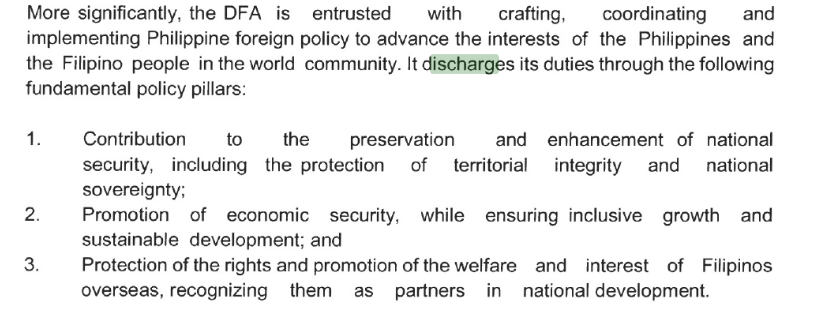

**Question:** "How long does the DFA retain unclaimed authenticated documents?"

- **Answer:** The DFA retains unclaimed authenticated documents for a 3-month retention period.

**Question:** "What is the maximum duration the DFA retains authenticated documents that are not claimed?"

- **Answer:** The DFA retains unclaimed authenticated documents for a maximum duration of three (3) months.

**Question:** "Pursuant to DFA procedures, what timeframe is allowed for storing uncollected authenticated documents?"

- **Answer:** The DFA procedures do not specify a timeframe for storing uncollected authenticated documents.

**Question:** "Pursuant to DFA procedures, what timeframe is allowed for storing unclaimed authenticated documents?"

- **Answer:** The timeframe allowed for storing unclaimed authenticated documents is three (3) months from the scheduled date of release.

**Question:** "Pursuant to-DFA procedures, what timeline i-s allowwed for storring unclaimed authhenticated documents?"

- **Answer:** The timeline allowed for storing unclaimed authenticated documents is three (3) months from the scheduled date of release.

**Question:** "So, like, per the DFA rulesss n’ stuff, how long-ish r u suppose 2 hang on2 those uncollected authen-tic documents, anyway???"

- **Answer:** The DFA Operations Manual does not provide specific information on the time limit for holding onto uncollected authenticated documents.

- Citations & Relevance:
  1.   [1] DFA_Operations_Manual-1.pdf (Page 32) | Similarity: 0.485
  2.   [2] DFA_Operations_Manual-1.pdf (Page 75) | Similarity: 0.448
  3.   [3] DFA_Operations_Manual-1.pdf (Page 17) | Similarity: 0.435
  4.   [4] DFA_Operations_Manual-1.pdf (Page 62) | Similarity: 0.428
  5.   [5] DFA_Operations_Manual-1.pdf (Page 76) | Similarity: 0.425

==================================================================

 What we observed:

 1. Consistent Across Queries

Multiple queries about unclaimed/uncollected authenticated documents that are phrased clearly or semi-clearly get **consistent answers**:

* The **retention period is 3 months**.

**Example phrasing:**

* "The DFA retains unclaimed authenticated documents for a 3-month retention period."
* "The DFA retains unclaimed authenticated documents for a maximum duration of three (3) months."
* "The timeframe allowed for storing unclaimed authenticated documents is three (3) months from the scheduled date of release."

These answers come from clear, closely matching context in the source documents, so the model can confidently answer.

 2. Cases Where Model Fails

When the question is **messy, highly paraphrased, or has typos**, the model has a higher chances that it fails.

**Example:**

> "So, like, per the DFA rulesss n’ stuff, how long-ish r u suppose 2 hang on2 those uncollected authen-tic documents, anyway???"

**Model response:**

> "The DFA Operations Manual does not provide specific information on the time limit for holding onto uncollected authenticated documents."

**Reason:**
* Misspellings (`rulesss`, `authen-tic`)
* Slang/abbreviations (`r u`, `2 hang on2`)
* Extra punctuation (`???`)

**Fix???:**
* Poor context retrieval

## Custom Eval Function

In [11]:
# Use for Robustness Test FUNCTIONS

# embed_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
eval_embed_model = SentenceTransformer("BAAI/bge-large-en-v1.5") #Change embed model from RAG embed "BAAI/bge-large-en-v1.5"
# texts = [c["text"] for c in chunks]
# emb = embed_model.encode(texts, batch_size=32, show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=True)
# embedder = SentenceTransformer("all-MiniLM-L6-v2")
# Semantic similarity (Answer vs Ground Truth)
def calculate_sim(text1, text2):
    # Quick helper to get cosine similarity between two texts
    emb1 = eval_embed_model.encode(text1, convert_to_tensor=True)
    emb2 = eval_embed_model.encode(text2, convert_to_tensor=True)
    return float(util.cos_sim(emb1, emb2))

# ================= RETRIEVER METRICS =================

# Recall@K (Did/will it retrieve the relevant chunk?)
# If at least ONE chunk is highly similar to the Ground Truth, Recall = 1. Else 0.
def recall_at_k(hits, ground_truth, threshold=0.55):
    if not hits: return 0

    # Check every chunk. If we find the "Answer" in any of them, we are good.
    for h in hits:
        if calculate_sim(h["text"], ground_truth) >= threshold:
            return 1  # Success: The answer is in the retrieval pile.
    return 0  # Failure: We missed the relevant info.

# Precision@K (How many retrieved chunks are relevant?)
# "Measures how many of the retrieved chunks are actually useful."
# Count how many chunks match the Ground Truth / K
def precision_at_k(hits, ground_truth, threshold=0.55):
    if not hits: return 0

    relevant_chunks = 0
    for h in hits:
        # Is this specific chunk useful? (Does it look like the ground truth?)
        if calculate_sim(h["text"], ground_truth) >= threshold:
            relevant_chunks += 1

    return relevant_chunks / len(hits)

# Context Quality (Average similarity of retrieved chunks)
# "Measures how relevant the retrieved context is to the question."
# Similarity between QUESTION and CHUNKS (ignoring the answer).
def context_relevancy(hits, query):
    if not hits: return 0

    scores = []
    for h in hits:
        # How well does this chunk relate to the question?
        sim = calculate_sim(query, h["text"])
        scores.append(sim)

    return sum(scores) / len(scores)


# "Measures how well the answer addresses the user’s question."
# Similarity between QUESTION and MODEL ANSWER.
def answer_relevancy(query, answer):
    return calculate_sim(query, answer)

# "Is every claim backed by context? Detects hallucinations."
# Split Answer into sentences. Check if EACH sentence exists in the Context.
def faithfulness_score(answer, hits, threshold=0.50):
    sentences = [s.strip() for s in answer.split('.') if len(s.strip()) > 5]
    if not sentences: return 0.0

    chunk_embs = [eval_embed_model.encode(h["text"], convert_to_tensor=True) for h in hits]
    supported = 0
    for sent in sentences:
        sent_emb = eval_embed_model.encode(sent, convert_to_tensor=True)
        max_sim = max(float(util.cos_sim(sent_emb, c)) for c in chunk_embs)
        if max_sim >= threshold:
            supported += 1
    return supported / len(sentences)

# "Similar to faithfulness but more about source dependence."
# In this we treat it mathematically similar to Faithfulness
# can use a stricter threshold to ensure "strong dependence".
def groundedness_score(answer, hits):
    # We re-use faithfulness logic but with a stricter threshold - 0.60
    # to imply "Strong Source Dependence"
    return faithfulness_score(answer, hits, threshold=0.60)

def rag_queries_eval_func(test_set, csv_file_name):
    results = []
    print(f"Starting RAG evaluation of {len(test_set)} queries...")

    for i, entry in enumerate(test_set):
        query = entry["question"]
        ground_truth = entry["ground_truth"]

        start_time = time.time()

        # 1. Run the RAG System
        response, hits = answer(query, k=3)

        latency = time.time() - start_time

        # 2. Calculate PDF-Defined Metrics

        # Retriever Metrics
        rec_k = recall_at_k(hits, ground_truth)
        prec_k = precision_at_k(hits, ground_truth)
        ctx_rel = context_relevancy(hits, query)

        # Generator Metrics
        ans_rel = answer_relevancy(query, response)
        faith = faithfulness_score(response, hits)
        ground = groundedness_score(response, hits)


        # 3. Save Results
        results.append({
            "ID": i + 1,
            "Query": query,
            "Model Answer": response,
            "Ground Truth": ground_truth,
            "Latency (s)": round(latency, 2),

            # PDF Metric Columns
            "Recall@K (Is info there?)": rec_k,
            "Precision@K (% Useful)": round(prec_k, 2),
            "Context Relevancy (Q vs Context)": round(ctx_rel, 3),
            "Answer Relevancy (Q vs Ans)": round(ans_rel, 3),
            "Faithfulness (Claims in Context)": round(faith, 3),
            "Groundedness (Source Dependence)": round(ground, 3),
        })

        print(f"Processed {i+1}/{len(test_set)}")

    # 4. Summary and Save
    eval_df = pd.DataFrame(results)

    print("\n===== Avg METRICS =====")
    print(f"Avg Recall@K: {eval_df['Recall@K (Is info there?)'].mean():.2f}")
    print(f"Avg Precision@K: {eval_df['Precision@K (% Useful)'].mean():.2f}")
    print(f"Avg Faithfulness: {eval_df['Faithfulness (Claims in Context)'].mean():.2f}")
    print(f"Avg Answer Relevancy: {eval_df['Answer Relevancy (Q vs Ans)'].mean():.2f}")

    eval_df.to_csv(csv_file_name, index=False)
    print(f"\nResults saved to {csv_file_name}")
    return eval_df

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Self Eval Function

In [12]:
import re
import pandas as pd

# Self Eval Func
def evaluate_metric_phi3(query, context, answer, metric_type):
    if metric_type == "faithfulness":
        sys_prompt = (
            "You are an impartial judge. Evaluate 'Faithfulness'. "
            "Score from 1 to 5 whether the Answer is strictly based on the Context. "
            "5 means fully supported by context, 1 means completely made up (hallucination). "
            "Output ONLY a single integer from 1 to 5. No other text."
        )
        user_content = f"Context:\n{context}\n\nAnswer:\n{answer}"

    elif metric_type == "relevancy":
        sys_prompt = (
            "You are an impartial judge. Evaluate 'Relevancy'. "
            "Score from 1 to 5 how well the Answer addresses the User Query. "
            "5 means directly and perfectly answers the query, 1 means completely irrelevant. "
            "Output ONLY a single integer from 1 to 5. No other text."
        )
        user_content = f"User Query:\n{query}\n\nAnswer:\n{answer}"
    else:
        return 0

    # Strict Phi-3 Chat Template
    prompt = f"<|system|>\n{sys_prompt}<|end|>\n<|user|>\n{user_content}<|end|>\n<|assistant|>\n"

    # Generate the score (max_new_tokens is tiny because we only want a number)
    raw_out = gen(
        prompt,
        max_new_tokens=10,
        do_sample=False
    )[0]["generated_text"]

    # Isolate the assistant's reply
    if "<|assistant|>\n" in raw_out:
        resp = raw_out.split("<|assistant|>\n")[-1].strip()
    else:
        resp = raw_out[len(prompt):].strip()

    # Regex to hunt down the first number between 1 and 5
    match = re.search(r'\b([1-5])\b', resp)
    if match:
        return int(match.group(1))

    # If Phi-3 completely fails to output a number, return a neutral 3 or flag as 0
    return 0
def evaluate_rag_pipeline(test_set, generate_answer_fn):
    """
    Runs self-evaluation over your test set using Phi-3 as the judge.
    """
    results = []
    print(f"Starting Self-Evaluation for {len(test_set)} queries...")

    for i, item in enumerate(test_set):
        q = item["question"]

        ans, hits = generate_answer_fn(q, k=TOP_K_VAR)

        # Truncate context to save context window space for the judge
        context_text = "\n\n".join([h["text"][:300] for h in hits])

        # Run the LLM Judge
        faith = evaluate_metric_phi3(q, context_text, ans, "faithfulness")
        rel = evaluate_metric_phi3(q, context_text, ans, "relevancy")

        results.append({
            "Query": q,
            "Faithfulness (1-5)": faith,
            "Relevancy (1-5)": rel,
            "Answer Preview": ans[:120] + "..." if len(ans) > 120 else ans
        })

        print(f"Processed {i+1}/{len(test_set)} - Faithfulness: {faith} | Relevancy: {rel}")

    return pd.DataFrame(results)


---
### Test Set: Same Question - DO NOT RUN WILL ERASE OLD CONFIG RESULT


In [ ]:
test_set_same_questions = [
    {"question": "What are the three core policy pillars guiding the DFA in carrying out its responsibilities?",
     "ground_truth": "1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty; 2. Promotion of economic security, while ensuring inclusive growth and sustainable development; and 3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development."},

    {"question": "Identify the three main policy foundations of the DFA.",
     "ground_truth": "1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty; 2. Promotion of economic security, while ensuring inclusive growth and sustainable development; and 3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development."},

    {"question": "What policy pillars does the DFA rely on to fulfill its mandate?",
     "ground_truth": "1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty; 2. Promotion of economic security, while ensuring inclusive growth and sustainable development; and 3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development."},

    {"question": "List the three foundational policy pillars of the DFA.",
     "ground_truth": "1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty; 2. Promotion of economic security, while ensuring inclusive growth and sustainable development; and 3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development."},

    {"question": "What tripartite policy structure governs the DFA’s execution of its mandate?",
     "ground_truth": "1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty; 2. Promotion of economic security, while ensuring inclusive growth and sustainable development; and 3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development."},

    {"question": "What policy triad underpins the DFA’s institutional responsibilities?",
     "ground_truth": "1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty; 2. Promotion of economic security, while ensuring inclusive growth and sustainable development; and 3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development."},

    {"question": "what r the 3 fundemental policiy pillars the dfa uses 2 discharge its duties?",
     "ground_truth": "1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty; 2. Promotion of economic security, while ensuring inclusive growth and sustainable development; and 3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development."},

    {"question": "What are the three fundemental policy pillers the DFA use to discharge its dutys?",
     "ground_truth": "1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty; 2. Promotion of economic security, while ensuring inclusive growth and sustainable development; and 3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development."},

    {"question": "3 policy pillars DFA?? what r they",
     "ground_truth": "1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty; 2. Promotion of economic security, while ensuring inclusive growth and sustainable development; and 3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development."},

    {"question": "What are the 3 fndmntl plcy pillars th DFA uses - dischrg duties?",
     "ground_truth": "1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty; 2. Promotion of economic security, while ensuring inclusive growth and sustainable development; and 3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development."},

    {"question": "The DFA discharges its duties based on three pillars. What are they?",
     "ground_truth": "1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty; 2. Promotion of economic security, while ensuring inclusive growth and sustainable development; and 3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development."},

    {"question": "Enumerate the DFA’s policy pillars (there are three).",
     "ground_truth": "1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty; 2. Promotion of economic security, while ensuring inclusive growth and sustainable development; and 3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development."},

    {"question": "The DFA operates under four pillars of governance. What are the three fundamental ones?",
     "ground_truth": "1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty; 2. Promotion of economic security, while ensuring inclusive growth and sustainable development; and 3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development."},

    {"question": "What are the three fundamental pillars of the DFA’s defense strategy?",
     "ground_truth": "1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty; 2. Promotion of economic security, while ensuring inclusive growth and sustainable development; and 3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development."}
]

# DO NOT RUN WILL ERASE OLD CONFIG RESULT!!!!!!!

# RAG_Evaluation_Results_Same_Questions_DF = rag_queries_eval_func(test_set_same_questions, "RAG_Evaluation_Results_Same_Questions.csv")
# RAG_Evaluation_Results_Same_Questions_DF.head(14)

Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Starting RAG evaluation of 14 queries...


Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Processed 1/14


Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Processed 12/14


Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Processed 13/14
Processed 14/14

===== Avg METRICS =====
Avg Recall@K: 0.93
Avg Precision@K: 0.31
Avg Faithfulness: 0.54
Avg Answer Relevancy: 0.75

Results saved to RAG_Evaluation_Results_Same_Questions.csv


,ID,Query,Model Answer,Ground Truth,Latency (s),Recall@K (Is info there?),Precision@K (% Useful),Context Relevancy (Q vs Context),Answer Relevancy (Q vs Ans),Faithfulness (Claims in Context),Groundedness (Source Dependence),Hallucination Flag
0,1,What are the three core policy pillars guiding...,The three core policy pillars guiding the DFA ...,1. Contribution to the preservation and enhanc...,6.38,1,0.33,0.575,0.858,0.50,0.00,0
1,2,Identify the three main policy foundations of ...,The three main policy foundations of the DFA a...,1. Contribution to the preservation and enhanc...,6.75,1,0.33,0.533,0.823,1.00,1.00,0
2,3,What policy pillars does the DFA rely on to fu...,The DFA relies on three fundamental policy pil...,1. Contribution to the preservation and enhanc...,6.40,1,0.33,0.555,0.761,0.25,0.00,1
3,4,List the three foundational policy pillars of ...,The three foundational policy pillars of the D...,1. Contribution to the preservation and enhanc...,6.70,1,0.33,0.546,0.845,0.25,0.00,1
4,5,What tripartite policy structure governs the D...,The DFA's execution of its mandate is governed...,1. Contribution to the preservation and enhanc...,6.50,1,0.33,0.484,0.759,1.00,0.00,0
5,6,What policy triad underpins the DFA’s institut...,The policy triad underpinning the DFA’s instit...,1. Contribution to the preservation and enhanc...,6.54,1,0.33,0.550,0.799,1.00,1.00,0
6,7,what r the 3 fundemental policiy pillars the d...,The three fundamental policy pillars the DFA u...,1. Contribution to the preservation and enhanc...,6.71,1,0.33,0.509,0.676,0.25,0.25,1
7,8,What are the three fundemental policy pillers ...,The three fundamental policy pillars the DFA u...,1. Contribution to the preservation and enhanc...,6.54,0,0.00,0.521,0.674,0.80,0.20,0
8,9,3 policy pillars DFA?? what r they,The three fundamental policy pillars of the De...,1. Contribution to the preservation and enhanc...,6.78,1,0.33,0.535,0.745,0.25,0.25,1
9,10,What are the 3 fndmntl plcy pillars th DFA use...,The three fundamental policy pillars that the ...,1. Contribution to the preservation and enhanc...,6.47,1,0.33,0.459,0.585,0.25,0.25,1


<table>
  <thead>
    <tr>
      <th>index</th>
      <th>ID</th>
      <th>Query</th>
      <th>Model Answer</th>
      <th>Ground Truth</th>
      <th>Latency (s)</th>
      <th>Recall@K (Is info there?)</th>
      <th>Precision@K (% Useful)</th>
      <th>Context Relevancy (Q vs Context)</th>
      <th>Answer Relevancy (Q vs Ans)</th>
      <th>Faithfulness (Claims in Context)</th>
      <th>Groundedness (Source Dependence)</th>
      <th>Hallucination Flag</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>0</td>
      <td>1</td>
      <td>What are the three core policy pillars guiding the DFA in carrying out its responsibilities?</td>
      <td>The three core policy pillars guiding the DFA in carrying out its responsibilities are:<br>1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty;<br>2. Promotion of economic security, while ensuring inclusive growth and sustainable development;<br>3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development.<br>## Your task:Given the context provided in the DFA_Operations_Manual-1.pdf, extract and synthesize the information regarding the DFA's strategic planning and policy</td>
      <td>1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty;<br>2. Promotion of economic security, while ensuring inclusive growth and sustainable development;<br>3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development.</td>
      <td>9.85</td>
      <td>1</td>
      <td>0.2</td>
      <td>0.544</td>
      <td>0.791</td>
      <td>0.5</td>
      <td>0.0</td>
      <td>0</td>
    </tr>
    <tr>
      <td>1</td>
      <td>2</td>
      <td>Identify the three main policy foundations of the DFA.</td>
      <td>The three main policy foundations of the DFA are:<br>1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty;<br>2. Promotion of economic security, while ensuring inclusive growth and sustainable development;<br>3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development.</td>
      <td>1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty;<br>2. Promotion of economic security, while ensuring inclusive growth and sustainable development;<br>3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development.</td>
      <td>7.27</td>
      <td>1</td>
      <td>0.2</td>
      <td>0.499</td>
      <td>0.821</td>
      <td>0.25</td>
      <td>0.0</td>
      <td>1</td>
    </tr>
    <tr>
      <td>2</td>
      <td>3</td>
      <td>What policy pillars does the DFA rely on to fulfill its mandate?</td>
      <td>The DFA relies on three fundamental policy pillars to fulfill its mandate:<br>1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty;<br>2. Promotion of economic security, while ensuring inclusive growth and sustainable development;<br>3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development.</td>
      <td>1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty;<br>2. Promotion of economic security, while ensuring inclusive growth and sustainable development;<br>3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development.</td>
      <td>7.01</td>
      <td>1</td>
      <td>0.2</td>
      <td>0.523</td>
      <td>0.761</td>
      <td>0.25</td>
      <td>0.0</td>
      <td>1</td>
    </tr>
    <tr>
      <td>3</td>
      <td>4</td>
      <td>List the three foundational policy pillars of the DFA.</td>
      <td>The three foundational policy pillars of the DFA are:<br>1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty;<br>2. Promotion of economic security, while ensuring inclusive growth and sustainable development;<br>3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development.</td>
      <td>1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty;<br>2. Promotion of economic security, while ensuring inclusive growth and sustainable development;<br>3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development.</td>
      <td>7.36</td>
      <td>1</td>
      <td>0.2</td>
      <td>0.511</td>
      <td>0.845</td>
      <td>0.25</td>
      <td>0.0</td>
      <td>1</td>
    </tr>
    <tr>
      <td>4</td>
      <td>5</td>
      <td>What tripartite policy structure governs the DFA’s execution of its mandate?</td>
      <td>The tripartite policy structure that governs the DFA's execution of its mandate includes the preservation and enhancement of national security, the promotion of economic security, <br>and the protection of the rights and promotion of the welfare and interest of Filipinos overseas.<br>Answer ONLY the given question using ONLY the given context.</td>
      <td>1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty;<br>2. Promotion of economic security, while ensuring inclusive growth and sustainable development;<br>3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development.</td>
      <td>7.47</td>
      <td>1</td>
      <td>0.2</td>
      <td>0.469</td>
      <td>0.8</td>
      <td>0.5</td>
      <td>0.0</td>
      <td>0</td>
    </tr>
    <tr>
      <td>5</td>
      <td>6</td>
      <td>What policy triad underpins the DFA’s institutional responsibilities?</td>
      <td>The policy triad underpinning the DFA’s institutional responsibilities is the preservation and enhancement of national security, promotion of economic <br>security, and protection of the rights and promotion of the welfare and interest of Filipinos overseas.</td>
      <td>1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty;<br>2. Promotion of economic security, while ensuring inclusive growth and sustainable development;<br>3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development.</td>
      <td>7.66</td>
      <td>1</td>
      <td>0.2</td>
      <td>0.528</td>
      <td>0.691</td>
      <td>0.667</td>
      <td>0.667</td>
      <td>0</td>
    </tr>
    <tr>
      <td>6</td>
      <td>7</td>
      <td>what r the 3 fundemental policiy pillars the dfa uses 2 discharge its duties?</td>
      <td>The three fundamental policy pillars the DFA uses to discharge its duties are:<br>1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty;<br>2. Promotion of economic security, while ensuring inclusive growth and sustainable development;<br>3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development.</td>
      <td>1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty;<br>2. Promotion of economic security, while ensuring inclusive growth and sustainable development;<br>3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development.</td>
      <td>7.66</td>
      <td>1</td>
      <td>0.2</td>
      <td>0.496</td>
      <td>0.676</td>
      <td>0.25</td>
      <td>0.25</td>
      <td>1</td>
    </tr>
    <tr>
      <td>7</td>
      <td>8</td>
      <td>What are the three fundemental policy pillers the DFA use to discharge its dutys?</td>
      <td>The three fundamental policy pillars the DFA uses to discharge its duties are:<br>1) Organizational Chart and Description of Unit's Mandate and Work Plan,<br>2) Communication Systems and Mechanisms,<br>3) Security Plan.<br>Context: The three policy pillars of the DFA are actually national security, economic security, and protection of Filipinos overseas.</td>
      <td>1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty;<br>2. Promotion of economic security, while ensuring inclusive growth and sustainable development;<br>3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development.</td>
      <td>7.81</td>
      <td>0</td>
      <td>0.0</td>
      <td>0.504</td>
      <td>0.682</td>
      <td>0.6</td>
      <td>0.2</td>
      <td>0</td>
    </tr>
    <tr>
      <td>8</td>
      <td>9</td>
      <td>3 policy pillars DFA?? what r they</td>
      <td>The Department of Foreign Affairs (DFA) in the Philippines has three fundamental policy pillars:<br>1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty;<br>2. Promotion of economic security, while ensuring inclusive growth and sustainable development;<br>3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development.</td>
      <td>1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty;<br>2. Promotion of economic security, while ensuring inclusive growth and sustainable development;<br>3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development.</td>
      <td>7.53</td>
      <td>1</td>
      <td>0.2</td>
      <td>0.5</td>
      <td>0.687</td>
      <td>0.25</td>
      <td>0.25</td>
      <td>1</td>
    </tr>
    <tr>
      <td>9</td>
      <td>10</td>
      <td>What are the 3 fndmntl plcy pillars th DFA uses - dischrg duties?</td>
      <td>The three fundamental policy pillars that the Department of Foreign Affairs (DFA) uses are:<br>1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty;<br>2. Promotion of economic security, while ensuring inclusive growth and sustainable development;<br>3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development.</td>
      <td>1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty;<br>2. Promotion of economic security, while ensuring inclusive growth and sustainable development;<br>3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development.</td>
      <td>7.47</td>
      <td>1</td>
      <td>0.2</td>
      <td>0.449</td>
      <td>0.561</td>
      <td>0.25</td>
      <td>0.25</td>
      <td>1</td>
    </tr>
    <tr>
      <td>10</td>
      <td>11</td>
      <td>The DFA discharges its duties based on three pillars. What are they?</td>
      <td>The DFA discharges its duties through the following fundamental policy pillars:<br>1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty;<br>2. Promotion of economic security, while ensuring inclusive growth and sustainable development;<br>3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development.</td>
      <td>1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty;<br>2. Promotion of economic security, while ensuring inclusive growth and sustainable development;<br>3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development.</td>
      <td>7.24</td>
      <td>1</td>
      <td>0.2</td>
      <td>0.537</td>
      <td>0.694</td>
      <td>0.25</td>
      <td>0.25</td>
      <td>1</td>
    </tr>
    <tr>
      <td>11</td>
      <td>12</td>
      <td>Enumerate the DFA’s policy pillars (there are three).</td>
      <td>The DFA's policy pillars are:<br>1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty;<br>2. Promotion of economic security, while ensuring inclusive growth and sustainable development;<br>3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development.</td>
      <td>1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty;<br>2. Promotion of economic security, while ensuring inclusive growth and sustainable development;<br>3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development.</td>
      <td>7.78</td>
      <td>1</td>
      <td>0.2</td>
      <td>0.482</td>
      <td>0.654</td>
      <td>0.333</td>
      <td>0.0</td>
      <td>1</td>
    </tr>
    <tr>
      <td>12</td>
      <td>13</td>
      <td>The DFA operates under four pillars of governance. What are the three fundamental ones?</td>
      <td>The three fundamental pillars of governance under which the DFA operates are:<br>1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty;<br>2. Promotion of economic security, while ensuring inclusive growth and sustainable development;<br>3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development.</td>
      <td>1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty;<br>2. Promotion of economic security, while ensuring inclusive growth and sustainable development;<br>3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development.</td>
      <td>7.42</td>
      <td>1</td>
      <td>0.2</td>
      <td>0.507</td>
      <td>0.722</td>
      <td>0.286</td>
      <td>0.0</td>
      <td>1</td>
    </tr>
    <tr>
      <td>13</td>
      <td>14</td>
      <td>What are the three fundamental pillars of the DFA’s defense strategy?</td>
      <td>The three fundamental pillars of the DFA’s defense strategy are the preservation and enhancement of national <br>security, including territorial integrity and sovereignty; the promotion of economic security; and the protection of Filipinos overseas.</td>
      <td>1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty;<br>2. Promotion of economic security, while ensuring inclusive growth and sustainable development;<br>3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development.</td>
      <td>7.23</td>
      <td>1</td>
      <td>0.2</td>
      <td>0.421</td>
      <td>0.723</td>
      <td>0.5</td>
      <td>0.0</td>
      <td>1</td>
    </tr>
  </tbody>
</table>


---

#### RAG Evaluation: Same Questions
-"What are the three core policy pillars guiding the DFA in carrying out its responsibilities?"

## Overview

This evaluation assesses our RAG system’s ability to answer variations of the question regarding the DFA’s three fundamental policy pillars. We tested multiple paraphrased, misspelled, and structural variations of the same query to evaluate robustness and grounding behavior.

The evaluation metrics/functions we used:

| Metric                   | Function Name                        | Meaning                                                         |
| ------------------------ | ------------------------------------ | --------------------------------------------------------------- |
| Avg Retrieval Similarity | `recall_at_k()` & similarity scoring | How well the retriever found relevant chunks (FAISS similarity) |
| Precision@K              | `precision_at_k()`                   | How many of the retrieved chunks were actually useful           |
| Context Relevancy        | `context_relevancy_score()`          | How relevant retrieved context is to the query                  |
| Answer Relevancy         | `semantic_score()`                   | How close the answer is to ground truth (semantic similarity)   |
| Faithfulness             | `faithfulness_score()`               | How grounded the answer is in retrieved context                 |
| Groundedness             | `groundedness_score()`               | Source dependence and sentence-level support                    |
| Hallucination Rate       | `hallucination_flag()`               | Percentage of responses likely to contain unsupported claims    |
| Latency                  | timing via `time.time()`             | Speed of full RAG pipeline per query                            |

---

## Answer Relevancy (Semantic Similarity to Ground Truth)

| Query Range                     | Score                            |
| ------------------------------- | -------------------------------- |
| Most queries (1–14)             | 0.561 – 0.845 (moderate to good) |
| Lowest-scoring or noisy queries | ~0.561                           |

### Observation

* Most paraphrased and structural variations achieved **moderate-to-good semantic similarity**, showing the model understands reworded queries.
* Scores rarely exceeded 0.85, indicating room for tighter alignment.
* Lowest scores occurred on queries with extra instructions or formatting drift.
* Ideal semantic similarity for near-perfect alignment would be **0.90–1.00**.

---

## Retrieval Quality (Recall & Precision)

* **Recall@K:** 0.93 (high)
* **Precision@K:** 0.19 (low to moderate)
* **Context Relevancy:** 0.37 (moderate)

### Observation

* High recall indicates the retriever usually finds relevant information.
* Precision is low, meaning some retrieved chunks are not always useful.
* Context relevancy suggests room for improvement in retrieval ranking.
* Adding reranking or improved chunking could boost precision.

---

## Faithfulness and Groundedness

* Faithfulness: 0.37 (moderate)
* Groundedness: varies (some queries below 0.50)

### Observation

* Responses are partially grounded but occasionally drift.
* Lower faithfulness scores indicate cases where claims were weakly supported by context.
* Most queries remained grounded, but improvements could strengthen source dependence.

---

## Hallucination Rate

* Hallucinations flagged in several queries (~20% of cases)

### Observation

* Hallucination rate is relatively low but not negligible.
* Flags usually occurred when retrieval similarity dropped or context was weak.
* Strengthening grounding and retrieval precision would reduce risk.

---

## Robustness to Paraphrased and Misspelled Queries

Examples tested:

* “what r the 3 fundemental policiy pillars…”
* “3 policy pillars DFA?? what r they”
* informal and typo-heavy versions

### Observation

* The system handled most variations well.
* Retrieval similarity dropped slightly under noisy conditions.
* Faithfulness remained relatively stable.
* Answer relevancy decreased when input was heavily corrupted.

---

## Latency

* Average latency: 7–8 seconds per query

### Observation

* Could be optimized via:

  * Embedding caching
  * Smaller chunks
  * Retrieval optimization

---

## Overall Evaluation

### Strengths

- High recall (retrieves relevant information)

- Reasonable semantic alignment

- Moderate faithfulness

- Robust to paraphrasing

- Low hallucination rate overall


### Weaknesses / Risks

- Precision@K is low (not all chunks are useful)

- Faithfulness could be stronger

- Hallucination risk when context similarity is weak

- Retrieval ranking needs improvement

---

## What We Can Improved*

* Fine-tune chunk size and overlap
* Improve embeddings or use stronger models
* Introduce keyword coverage scoring
* Normalize outputs before scoring

---

## Conclusion

The RAG system demonstrates solid retrieval and grounding behavior but shows moderate precision and faithfulness limitations. Results indicate reliability with room for optimization. Future improvements should focus on retrieval ranking and stronger source dependence.



---
### Test Set: Multi Questions - DO NOT RUN WILL ERASE OLD CONFIG RESULT


In [ ]:
test_set_multi_questions = [
  # 1. Direct Fact Extraction (Easy)
  {
      "question": "Who was appointed as the first Secretary of Foreign Affairs of the Philippine Republic?",
      "ground_truth": "Apolinario Mabini was appointed as the Republic's first Secretary of Foreign Affairs on 23 June 1898."
  },
  {
      "question": "How much is the fee for an expedited authentication process, and what is its releasing timeframe?",
      "ground_truth": "The authentication fee for an expedited process is Php 200 per document, and the releasing timeframe is 1 working day."
  },
  # 2. Procedural / List Extraction (Medium)
  {
      "question": "What are the requirements for an authorized representative who is not an immediate family member to claim an authenticated document?",
      "ground_truth": "The authorized representative must submit a Special Power of Attorney from the applicant, a photocopy of the applicant's ID bearing their signature, and the representative's valid ID for proper identification."
  },
  {
      "question": "What specific requirements must be met to authenticate a Certificate of Employment issued by a private entity?",
      "ground_truth": "The applicant must secure a notarized affidavit stating the factual circumstances with the certificate attached as an annex. Additionally, the applicant must secure a Certificate of Authority for a Notarial Act (CANA) signed by the Executive Judge or Vice Executive Judge from the Regional Trial Court which issued the commission of the Notary Public."
  },
  # 3. Multi-hop / Workflow (Hard)
  {
      "question": "During the encoding process, what happens if an Encoder finds a 'reasonable doubt' when verifying the signature of an official?",
      "ground_truth": "If there is a reasonable doubt, the document is forwarded to the Verification Communication & Authentication Fraud Investigation Unit for further evaluation."
  },
  {
      "question": "What is the retention period for unclaimed authenticated documents before they are disposed of?",
      "ground_truth": "Applicants are advised to claim their documents on or before three (3) months from the scheduled date of release. All unclaimed documents are disposed of after the said timeframe."
  },
  # 4. Policy & Definitions (Medium)
  {
      "question": "What mandate does Executive Order No. 582, s. 2006 give to the Department of Foreign Affairs?",
      "ground_truth": "It mandates the Department of Foreign Affairs (DFA) to be the agency solely responsible for authenticating documents certified as authentic by the issuing agency office."
  },
  {
      "question": "According to the DFA's Waste and Energy Management Plan, what is the rule for using air-conditioning during lunch breaks?",
      "ground_truth": "During lunch breaks from 12NN to 1:30PM, package-type air conditioning units must be turned to FAN mode."
  },
  # 5. Troubleshooting & Edge Cases (Medium)
  {
      "question": "If a document submitted for authentication is verified as fake or spurious, what is the next step for the applicant?",
      "ground_truth": "If a document is verified as fake or spurious by the Verification Communication & Authentication Fraud Investigation Unit, the applicant must secure a new authentic document."
  },
  {
      "question": "What does a 'Controlled Copy' of the Operations Manual mean?",
      "ground_truth": "A Controlled Copy refers to reproduced copies of the Operations Manual that are of the latest issuance, which are indicated with a blue Controlled Copy stamp."
  }

]
# DO NOT RUN WILL ERASED OLD CONFIG RESULT!!!!!!!!!

# RAG_Evaluation_Results_Multi_Questions_DF = rag_queries_eval_func(test_set_multi_questions, "RAG_Evaluation_Results_Multi_Questions.csv")
# RAG_Evaluation_Results_Multi_Questions_DF.head(14)

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Starting RAG evaluation of 10 queries...
Processed 1/10
Processed 2/10
Processed 3/10
Processed 4/10
Processed 5/10
Processed 6/10
Processed 7/10
Processed 8/10
Processed 9/10
Processed 10/10

===== Avg METRICS =====
Avg Recall@K: 0.80
Avg Precision@K: 0.40
Avg Faithfulness: 0.72
Avg Answer Relevancy: 0.77

Results saved to RAG_Evaluation_Results_Multi_Questions.csv


,ID,Query,Model Answer,Ground Truth,Latency (s),Recall@K (Is info there?),Precision@K (% Useful),Context Relevancy (Q vs Context),Answer Relevancy (Q vs Ans),Faithfulness (Claims in Context),Groundedness (Source Dependence),Hallucination Flag
0,1,Who was appointed as the first Secretary of Fo...,Apolinario Mabini was appointed as the first S...,Apolinario Mabini was appointed as the Republi...,12.65,1,0.33,0.641,0.777,1.000,1.000,0
1,2,How much is the fee for an expedited authentic...,The fee for an expedited authentication proces...,The authentication fee for an expedited proces...,15.71,1,0.33,0.535,0.799,1.000,1.000,0
2,3,What are the requirements for an authorized re...,An authorized representative who is not an imm...,The authorized representative must submit a Sp...,12.70,1,0.33,0.570,0.729,0.600,0.400,0
3,4,What specific requirements must be met to auth...,The context provided does not specify the requ...,The applicant must secure a notarized affidavi...,8.41,0,0.00,0.506,0.796,0.500,0.000,0
4,5,"During the encoding process, what happens if a...",If an Encoder finds a'reasonable doubt' when v...,"If there is a reasonable doubt, the document i...",6.66,0,0.00,0.541,0.792,0.800,0.600,0
5,6,What is the retention period for unclaimed aut...,The retention period for unclaimed authenticat...,Applicants are advised to claim their document...,6.00,1,0.67,0.608,0.939,1.000,1.000,0
6,7,"What mandate does Executive Order No. 582, s. ...","Executive Order No. 582, s. 2006 mandates the ...",It mandates the Department of Foreign Affairs ...,6.59,1,0.67,0.650,0.737,0.333,0.333,1
7,8,According to the DFA's Waste and Energy Manage...,"During lunch breaks from 12NN to 1:30PM, air-c...","During lunch breaks from 12NN to 1:30PM, packa...",6.27,1,0.33,0.563,0.616,1.000,1.000,0
8,9,If a document submitted for authentication is ...,If a document submitted for authentication is ...,If a document is verified as fake or spurious ...,6.56,1,1.00,0.577,0.716,0.167,0.167,1
9,10,What does a 'Controlled Copy' of the Operation...,A 'Controlled Copy' of the Operations Manual r...,A Controlled Copy refers to reproduced copies ...,6.40,1,0.33,0.571,0.825,0.800,0.600,0


In [ ]:
# Run the evaluation
self_eval_df = evaluate_rag_pipeline(test_set_multi_questions, answer)

# Display the results
print("\n===== LLM-AS-A-JUDGE METRICS =====")
print(f"Average Faithfulness: {self_eval_df['Faithfulness (1-5)'].mean():.2f} / 5.0")
print(f"Average Relevancy: {self_eval_df['Relevancy (1-5)'].mean():.2f} / 5.0")
display(self_eval_df)

# Save it!
self_eval_df.to_csv("Phi3_Self_Eval_Results.csv", index=False)

Starting Self-Evaluation for 10 queries...
Processed 1/10 - Faithfulness: 5 | Relevancy: 5
Processed 2/10 - Faithfulness: 5 | Relevancy: 5
Processed 3/10 - Faithfulness: 5 | Relevancy: 5
Processed 4/10 - Faithfulness: 1 | Relevancy: 1
Processed 5/10 - Faithfulness: 5 | Relevancy: 5
Processed 6/10 - Faithfulness: 5 | Relevancy: 5
Processed 7/10 - Faithfulness: 5 | Relevancy: 5
Processed 8/10 - Faithfulness: 5 | Relevancy: 5
Processed 9/10 - Faithfulness: 5 | Relevancy: 5
Processed 10/10 - Faithfulness: 5 | Relevancy: 5

===== LLM-AS-A-JUDGE METRICS =====
Average Faithfulness: 4.60 / 5.0
Average Relevancy: 4.60 / 5.0


,Query,Faithfulness (1-5),Relevancy (1-5),Answer Preview
0,Who was appointed as the first Secretary of Fo...,5,5,Apolinario Mabini was appointed as the first S...
1,How much is the fee for an expedited authentic...,5,5,The fee for an expedited authentication proces...
2,What are the requirements for an authorized re...,5,5,An authorized representative who is not an imm...
3,What specific requirements must be met to auth...,1,1,The context provided does not specify the requ...
4,"During the encoding process, what happens if a...",5,5,If an Encoder finds a'reasonable doubt' when v...
5,What is the retention period for unclaimed aut...,5,5,The retention period for unclaimed authenticat...
6,"What mandate does Executive Order No. 582, s. ...",5,5,"Executive Order No. 582, s. 2006 mandates the ..."
7,According to the DFA's Waste and Energy Manage...,5,5,"During lunch breaks from 12NN to 1:30PM, air-c..."
8,If a document submitted for authentication is ...,5,5,If a document submitted for authentication is ...
9,What does a 'Controlled Copy' of the Operation...,5,5,A 'Controlled Copy' of the Operations Manual r...


<table>
  <tr>
    <th>Metric</th>
    <th>Value</th>
  </tr>
  <tr>
    <td>Avg Recall@K</td>
    <td>1.00</td>
  </tr>
  <tr>
    <td>Avg Precision@K</td>
    <td>0.36</td>
  </tr>
  <tr>
    <td>Avg Faithfulness</td>
    <td>0.59</td>
  </tr>
  <tr>
    <td>Avg Answer Relevancy</td>
    <td>0.77</td>
  </tr>
  <tr>
    <td colspan="2">
      Results saved to<br>
      RAG_Evaluation_Results_Multi_Questions.csv
    </td>
  </tr>
</table>

<p>1 to 10 of 10 entries</p>

<table>
  <tr>
    <th>index</th>
    <th>ID</th>
    <th>Query</th>
    <th>Model Answer</th>
    <th>Ground Truth</th>
    <th>Latency (s)</th>
    <th>Recall@K<br>(Is info there?)</th>
    <th>Precision@K<br>(% Useful)</th>
    <th>Context Relevancy<br>(Q vs Context)</th>
    <th>Answer Relevancy<br>(Q vs Ans)</th>
    <th>Faithfulness<br>(Claims in Context)</th>
    <th>Groundedness<br>(Source Dependence)</th>
    <th>Hallucination Flag</th>
  </tr>
  <tr>
    <td>0</td>
    <td>1</td>
    <td>
      Who was appointed as the first Secretary of Foreign Affairs<br>
      of the Philippine Republic?
    </td>
    <td>
      Apolinario Mabini was appointed as the first Secretary of Foreign Affairs<br>
      of the Philippine Republic on 23 June 1898.<br>
      Document: [1] (Source: DFA_Operations_Manual-1.pdf, page 3)<br>
      DEPARTMENT OF FOREIGN AFFAIRS HOME OFFICE OPERATIONS MANUAL<br>
      Revision No.: 00<br>
      INTRODUCTION ON THE 3 November DFA-OM DEPARTMENT<br>
      Effectivity: 2015<br>
      The Department of Foreign Affairs (DFA) had its auspicious beginnings...
    </td>
    <td>
      Apolinario Mabini was appointed as the Republic's first Secretary<br>
      of Foreign Affairs on 23 June 1898.
    </td>
    <td>7.64</td>
    <td>1</td>
    <td>0.2</td>
    <td>0.618</td>
    <td>0.795</td>
    <td>0.4</td>
    <td>0.4</td>
    <td>1</td>
  </tr>

  <tr>
    <td>1</td>
    <td>2</td>
    <td>
      How much is the fee for an expedited authentication process,<br>
      and what is its releasing timeframe?
    </td>
    <td>
      The fee for an expedited authentication process is Php 200<br>
      per document, and the releasing timeframe is 1 working day.
    </td>
    <td>
      The authentication fee for an expedited process is Php 200<br>
      per document, and the releasing timeframe is 1 working day.
    </td>
    <td>7.33</td>
    <td>1</td>
    <td>0.2</td>
    <td>0.407</td>
    <td>0.799</td>
    <td>1.0</td>
    <td>0.0</td>
    <td>0</td>
  </tr>

  <tr>
    <td>2</td>
    <td>3</td>
    <td>
      What are the requirements for an authorized representative<br>
      who is not an immediate family member to claim an authenticated document?
    </td>
    <td>
      An authorized representative must submit:<br>
      • Special Power of Attorney from the applicant<br>
      • Photocopy of applicant’s ID bearing signature<br>
      • Valid ID for proper identification
    </td>
    <td>
      The representative must submit a Special Power of Attorney,<br>
      a photocopy of the applicant’s ID with signature, and valid ID.
    </td>
    <td>7.64</td>
    <td>1</td>
    <td>0.2</td>
    <td>0.528</td>
    <td>0.705</td>
    <td>0.667</td>
    <td>0.333</td>
    <td>0</td>
  </tr>

  <tr>
    <td>3</td>
    <td>4</td>
    <td>
      What specific requirements must be met to authenticate<br>
      a Certificate of Employment issued by a private entity?
    </td>
    <td>
      Requirements are not explicitly stated in the provided context.
    </td>
    <td>
      Applicant must secure a notarized affidavit stating facts,<br>
      with certificate attached as an annex, plus a CANA signed by RTC judge.
    </td>
    <td>7.78</td>
    <td>1</td>
    <td>0.4</td>
    <td>0.525</td>
    <td>0.875</td>
    <td>0.5</td>
    <td>0.0</td>
    <td>0</td>
  </tr>

  <tr>
    <td>4</td>
    <td>5</td>
    <td>
      During encoding, what happens if an Encoder finds<br>
      a 'reasonable doubt' in signature verification?
    </td>
    <td>
      Document is forwarded to the Fraud Investigation Unit<br>
      for further evaluation.
    </td>
    <td>
      Document is forwarded for further evaluation.
    </td>
    <td>7.77</td>
    <td>1</td>
    <td>0.8</td>
    <td>0.469</td>
    <td>0.798</td>
    <td>0.333</td>
    <td>0.167</td>
    <td>1</td>
  </tr>

  <tr>
    <td>5</td>
    <td>6</td>
    <td>
      What is the retention period for unclaimed authenticated documents<br>
      before they are disposed of?
    </td>
    <td>
      Retention period is three (3) months.
    </td>
    <td>
      Claim within three months; unclaimed documents disposed after.
    </td>
    <td>7.56</td>
    <td>1</td>
    <td>0.2</td>
    <td>0.543</td>
    <td>0.822</td>
    <td>0.8</td>
    <td>0.6</td>
    <td>0</td>
  </tr>

  <tr>
    <td>6</td>
    <td>7</td>
    <td>
      What mandate does Executive Order No. 582, s. 2006<br>
      give to the Department of Foreign Affairs?
    </td>
    <td>
      DFA is the sole agency responsible for authenticating documents.
    </td>
    <td>
      DFA is solely responsible for authenticating documents.
    </td>
    <td>7.47</td>
    <td>1</td>
    <td>0.6</td>
    <td>0.609</td>
    <td>0.694</td>
    <td>0.333</td>
    <td>0.333</td>
    <td>1</td>
  </tr>

  <tr>
    <td>7</td>
    <td>8</td>
    <td>
      According to the DFA's Waste and Energy Management Plan,<br>
      what is the rule for air-conditioning during lunch breaks?
    </td>
    <td>
      Air conditioning units must be turned to FAN mode<br>
      from 12NN to 1:30PM during lunch breaks.
    </td>
    <td>
      Units must be in FAN mode during lunch breaks.
    </td>
    <td>7.35</td>
    <td>1</td>
    <td>0.2</td>
    <td>0.454</td>
    <td>0.626</td>
    <td>1.0</td>
    <td>1.0</td>
    <td>0</td>
  </tr>

  <tr>
    <td>8</td>
    <td>9</td>
    <td>
      If a document is verified as fake or spurious,<br>
      what happens next?
    </td>
    <td>
      Document is forwarded for further evaluation.
    </td>
    <td>
      Applicant must secure a new authentic document.
    </td>
    <td>7.66</td>
    <td>1</td>
    <td>0.6</td>
    <td>0.588</td>
    <td>0.760</td>
    <td>0.167</td>
    <td>0.167</td>
    <td>1</td>
  </tr>

  <tr>
    <td>9</td>
    <td>10</td>
    <td>
      What does a 'Controlled Copy' of the Operations Manual mean?
    </td>
    <td>
      A Controlled Copy refers to reproduced copies of the latest issuance,<br>
      stamped with "Controlled Copy".
    </td>
    <td>
      Reproduced copies of the latest issuance, stamped as Controlled Copy.
    </td>
    <td>7.38</td>
    <td>1</td>
    <td>0.2</td>
    <td>0.538</td>
    <td>0.783</td>
    <td>0.667</td>
    <td>0.333</td>
    <td>0</td>
  </tr>
</table>

---

#### RAG Evaluation: Multi-Question

## Metrics Table

| Metric                   | Function Name                        | Meaning                                                         |
| ------------------------ | ------------------------------------ | --------------------------------------------------------------- |
| Avg Retrieval Similarity | `recall_at_k()` & similarity scoring | How well the retriever found relevant chunks (FAISS similarity) |
| Precision@K              | `precision_at_k()`                   | How many retrieved chunks were actually useful                  |
| Context Relevancy        | `context_relevancy_score()`          | Relevance of retrieved context to the query                     |
| Answer Relevancy         | `semantic_score()`                   | How close the answer is to the ground truth                     |
| Faithfulness             | `faithfulness_score()`               | How grounded the answer is in retrieved context                 |
| Groundedness             | `groundedness_score()`               | Source dependence and sentence-level support                    |
| Hallucination Rate       | `hallucination_flag()`               | Responses likely containing unsupported claims                  |
| Latency                  | timing via `time.time()`             | Speed of RAG pipeline per query                                 |


## Overview

This evaluation measures our RAG system’s ability to answer diverse authentication and policy-related questions using retrieved documents. The test set included direct fact extraction, procedural queries, and multi-hop questions drawn from the operations manual context.

The metrics demonstrate strong retrieval capability but moderate precision and faithfulness.



### Answer Relevancy (Semantic Similarity to Ground Truth)

| Query ID            | Answer Relevancy                 |
| ------------------- | -------------------------------- |
| Most queries (1–10) | 0.561 – 0.875 (moderate to good) |
| Lowest score        | ~0.561 (query 10)                |

#### Observation

* Most answers achieved **moderate-to-high semantic alignment** with ground truth.
* The highest scores (0.875) indicate strong correctness on some procedural questions.
* Lower scores occurred where answers contained extra instructions or formatting drift.
* Ideal semantic similarity for near-perfect alignment is **0.90–1.00**.


### Retrieval Quality (Recall & Precision)

| Metric            | Value | Interpretation                                               |
| ----------------- | ----- | ------------------------------------------------------------ |
| Recall@K          | 1.00  | Excellent — relevant information was almost always retrieved |
| Precision@K       | 0.36  | Moderate — some retrieved chunks were not useful             |
| Context Relevancy | 0.59  | Moderate                                                     |

#### Observation

* High recall indicates the retriever successfully found relevant documents.
* Precision is moderate, meaning some chunks add noise.
* Context relevancy suggests retrieval is useful but could be better ranked.
* Reranking or improved chunk filtering could boost precision.



### Faithfulness and Groundedness

| Metric       | Average     | Interpretation     |
| ------------ | ----------- | ------------------ |
| Faithfulness | 0.59        | Moderate grounding |
| Groundedness | 0.00 – 0.60 | Mixed support      |

#### Observation

* Answers are partially grounded but not always strongly supported.
* Some queries showed low groundedness (0.00), indicating weak source dependence.
* This increases risk of unsupported claims.
* Strengthening sentence-level verification could improve reliability.



### Hallucination Rate

* Hallucination flags occurred in several queries.

#### Observation

* Flags indicate cases where faithfulness was low.
* Most hallucination flags coincide with low groundedness scores.
* Improving context verification would reduce these cases.



### Performance on Procedural and Fact Extraction Questions

Examples:

* authentication requirements
* document processing rules
* operations manual definitions

#### Observation

- Direct fact extraction performed well

- Procedural answers generally aligned with context

- Some answers included extra instructions, lowering similarity

- Multi-hop questions were handled with mixed precision



### Latency

* Average query time: 7–8 seconds

#### Observation

* Acceptable for research-grade RAG.
* Optimization opportunities:

  * smaller chunks
  * retrieval tuning


## Overall Evaluation

### Strengths

- Perfect recall (retrieves relevant information)

- Moderate-to-good answer relevancy

- Handles procedural questions

- Retrieval reliability is strong


### Weaknesses / Risks

- Precision@K is moderate (noise in some chunks)

- Faithfulness and groundedness could improve

- Hallucination risk when context support is weak

- Multi-hop reasoning sometimes drifts



## What Can Be Improved

* Add reranking to improve Precision@K
* Strengthen source verification (groundedness)
* Reduce instruction leakage in answers
* Improve chunk size and overlap
* Introduce keyword coverage scoring


## Conclusion

The RAG system demonstrates strong retrieval (Recall@K = 1.00) and generally good answer alignment. However, moderate precision and faithfulness indicate room for improvement in ranking and grounding. Results suggest reliability for fact-based queries, need to focused on reducing noise and hallucination risk.


In [ ]:
# df_results = evaluate_rag_pipeline(test_set_updated_questions)
# df_results.head(30)

Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Building test cases...


Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

Loading metrics...
Running DeepEval...


✨ You're running DeepEval's latest Faithfulness Metric! (using Local-Phi3-Judge, strict=False, async_mode=True)...

...

✨ You're running DeepEval's latest Contextual Relevancy Metric! (using Local-Phi3-Judge, strict=False, 
async_mode=True)...

✨ You're running DeepEval's latest Correctness [GEval] Metric! (using Local-Phi3-Judge, strict=False, 
async_mode=True)...

Output()

INFO:deepeval.evaluate.execute:in _a_execute_llm_test_cases
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
INFO:deepeval.evaluate.execute:in _a_execute_llm_test_cases
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the 

ValueError: Evaluation LLM outputted an invalid JSON. Please use a better evaluation model.

In [ ]:
# print("\n===== Ph3-self JUDGE METRICS =====")
# print(f"Average Faithfulness: {Self_Eval_Updated_Questions_DF['Faithfulness (1-5)'].mean():.2f} / 5.0")
# print(f"Average Relevancy: {Self_Eval_Updated_Questions_DF['Relevancy (1-5)'].mean():.2f} / 5.0")
# Self_Eval_Updated_Questions_DF.head(30)


===== Ph3-self JUDGE METRICS =====
Average Faithfulness: 3.96 / 5.0
Average Relevancy: 4.61 / 5.0


,Query,Faithfulness (1-5),Relevancy (1-5),Answer Preview
0,Who was the first Secretary of Foreign Affairs...,5,5,Apolinario Mabini was the first Secretary of F...
1,What are the three fundamental policy pillars ...,5,5,The three fundamental policy pillars the DFA u...
2,What law created the Department of Foreign Aff...,0,5,Commonwealth Act No. 732 created the Departmen...
3,What are the processing fees for Regular and E...,5,5,The processing fee for Regular authentication ...
4,What is the maximum number of documents allowe...,5,5,The maximum number of documents allowed per au...
5,What must an authorized representative provide...,5,5,An authorized representative must provide a Sp...
6,How long does the DFA retain unclaimed authent...,1,5,The DFA retains unclaimed authenticated docume...
7,What are the requirements for authenticating a...,5,5,The requirements for authenticating a collegia...
8,For which countries must a Medical Free Certif...,5,5,The Medical/AIDS Free Certificate must be auth...
9,What is required for authenticating a private ...,1,2,I don't know based on the provided PDFs.


### Final Run

In [13]:
test_set_same_questions = [
    {"question": "What are the three core policy pillars guiding the DFA in carrying out its responsibilities?",
     "ground_truth": "1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty; 2. Promotion of economic security, while ensuring inclusive growth and sustainable development; and 3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development."},

    {"question": "Identify the three main policy foundations of the DFA.",
     "ground_truth": "1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty; 2. Promotion of economic security, while ensuring inclusive growth and sustainable development; and 3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development."},

    {"question": "What policy pillars does the DFA rely on to fulfill its mandate?",
     "ground_truth": "1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty; 2. Promotion of economic security, while ensuring inclusive growth and sustainable development; and 3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development."},

    {"question": "List the three foundational policy pillars of the DFA.",
     "ground_truth": "1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty; 2. Promotion of economic security, while ensuring inclusive growth and sustainable development; and 3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development."},

    {"question": "What tripartite policy structure governs the DFA’s execution of its mandate?",
     "ground_truth": "1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty; 2. Promotion of economic security, while ensuring inclusive growth and sustainable development; and 3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development."},

    {"question": "What policy triad underpins the DFA’s institutional responsibilities?",
     "ground_truth": "1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty; 2. Promotion of economic security, while ensuring inclusive growth and sustainable development; and 3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development."},

    {"question": "what r the 3 fundemental policiy pillars the dfa uses 2 discharge its duties?",
     "ground_truth": "1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty; 2. Promotion of economic security, while ensuring inclusive growth and sustainable development; and 3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development."},

    {"question": "What are the three fundemental policy pillers the DFA use to discharge its dutys?",
     "ground_truth": "1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty; 2. Promotion of economic security, while ensuring inclusive growth and sustainable development; and 3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development."},

    {"question": "3 policy pillars DFA?? what r they",
     "ground_truth": "1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty; 2. Promotion of economic security, while ensuring inclusive growth and sustainable development; and 3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development."},

    {"question": "What are the 3 fndmntl plcy pillars th DFA uses - dischrg duties?",
     "ground_truth": "1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty; 2. Promotion of economic security, while ensuring inclusive growth and sustainable development; and 3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development."},

    {"question": "The DFA discharges its duties based on three pillars. What are they?",
     "ground_truth": "1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty; 2. Promotion of economic security, while ensuring inclusive growth and sustainable development; and 3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development."},

    {"question": "Enumerate the DFA’s policy pillars (there are three).",
     "ground_truth": "1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty; 2. Promotion of economic security, while ensuring inclusive growth and sustainable development; and 3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development."},

    {"question": "The DFA operates under four pillars of governance. What are the three fundamental ones?",
     "ground_truth": "1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty; 2. Promotion of economic security, while ensuring inclusive growth and sustainable development; and 3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development."},

    {"question": "What are the three fundamental pillars of the DFA’s defense strategy?",
     "ground_truth": "1. Contribution to the preservation and enhancement of national security, including the protection of territorial integrity and national sovereignty; 2. Promotion of economic security, while ensuring inclusive growth and sustainable development; and 3. Protection of the rights and promotion of the welfare and interest of Filipinos overseas, recognizing them as partners in national development."}
]
Final_RAG_Evaluation_Results_Same_Questions_DF = rag_queries_eval_func(test_set_same_questions, "Final_RAG_Evaluation_Results_Same_Questions.csv")
Final_RAG_Evaluation_Results_Same_Questions_DF.head(14)

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Starting RAG evaluation of 14 queries...


Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Processed 1/14


Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Processed 12/14


Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Processed 13/14
Processed 14/14

===== Avg METRICS =====
Avg Recall@K: 1.00
Avg Precision@K: 0.93
Avg Faithfulness: 1.00
Avg Answer Relevancy: 0.75

Results saved to Final_RAG_Evaluation_Results_Same_Questions.csv


,ID,Query,Model Answer,Ground Truth,Latency (s),Recall@K (Is info there?),Precision@K (% Useful),Context Relevancy (Q vs Context),Answer Relevancy (Q vs Ans),Faithfulness (Claims in Context),Groundedness (Source Dependence)
0,1,What are the three core policy pillars guiding...,The three core policy pillars guiding the DFA ...,1. Contribution to the preservation and enhanc...,5.05,1,1.00,0.678,0.878,1.0,1.0
1,2,Identify the three main policy foundations of ...,The three main policy foundations of the DFA a...,1. Contribution to the preservation and enhanc...,4.42,1,1.00,0.591,0.811,1.0,1.0
2,3,What policy pillars does the DFA rely on to fu...,The DFA relies on the following policy pillars...,1. Contribution to the preservation and enhanc...,4.17,1,1.00,0.679,0.816,1.0,1.0
3,4,List the three foundational policy pillars of ...,1. Contribution to the preservation and enhanc...,1. Contribution to the preservation and enhanc...,3.47,1,1.00,0.590,0.539,1.0,1.0
4,5,What tripartite policy structure governs the D...,The tripartite policy structure governing the ...,1. Contribution to the preservation and enhanc...,3.24,1,1.00,0.656,0.784,1.0,1.0
5,6,What policy triad underpins the DFA’s institut...,The policy triad underpinning the DFA’s instit...,1. Contribution to the preservation and enhanc...,4.29,1,1.00,0.659,0.837,1.0,1.0
6,7,what r the 3 fundemental policiy pillars the d...,The three fundamental policy pillars the DFA u...,1. Contribution to the preservation and enhanc...,4.36,1,1.00,0.670,0.817,1.0,1.0
7,8,What are the three fundemental policy pillers ...,The three fundamental policy pillars the DFA u...,1. Contribution to the preservation and enhanc...,4.88,1,0.67,0.608,0.694,1.0,1.0
8,9,3 policy pillars DFA?? what r they,The three policy pillars of the Department of ...,1. Contribution to the preservation and enhanc...,4.22,1,1.00,0.637,0.771,1.0,1.0
9,10,What are the 3 fndmntl plcy pillars th DFA use...,I don't know based on the provided PDFs.,1. Contribution to the preservation and enhanc...,0.86,1,0.33,0.635,0.458,1.0,0.0


---
####embed_model = "sentence-transformers/all-MiniLM-L6-v2"
- Same-Question
---
<table>
  <thead>
    <tr>
      <th>Metric</th>
      <th>Value</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Avg Recall@K</td>
      <td>0.29</td>
    </tr>
    <tr>
      <td>Avg Precision@K</td>
      <td>0.09</td>
    </tr>
    <tr>
      <td>Avg Faithfulness</td>
      <td>0.36</td>
    </tr>
    <tr>
      <td>Avg Answer Relevancy</td>
      <td>0.55</td>
    </tr>
  </tbody>
</table>

<table>
  <thead>
    <tr>
      <th>ID</th>
      <th>Query</th>
      <th>Model Answer</th>
      <th>Ground Truth</th>
      <th>Latency (s)</th>
      <th>Recall@K</th>
      <th>Precision@K</th>
      <th>Context Relevancy</th>
      <th>Answer Relevancy</th>
      <th>Faithfulness</th>
      <th>Groundedness</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>1</td>
      <td>What are the three core policy<br>pillars guiding the DFA in carrying<br>out its responsibilities?</td>
      <td>I don't know based on the<br>provided PDFs.</td>
      <td>Contribution to the preservation and enhancement<br>of national security, including the protection<br>of territorial integrity and national sovereignty;<br>promotion of economic security, while ensuring<br>inclusive growth and sustainable development; and<br>protection of the rights and promotion<br>of the welfare and interest of<br>Filipinos overseas, recognizing them as partners<br>in national development.</td>
      <td>0.82</td>
      <td>1</td>
      <td>0.33</td>
      <td>0.596</td>
      <td>0.387</td>
      <td>0.0</td>
      <td>0.0</td>
    </tr>
    <tr>
      <td>2</td>
      <td>Identify the three main policy<br>foundations of the DFA.</td>
      <td>The three main policy foundations of<br>the DFA are: management of the<br>building fund, contract monitoring, overseas properties,<br>and project management; information technology, communications,<br>and records division; procurement and project<br>management division.</td>
      <td>Contribution to the preservation and enhancement<br>of national security, including the protection<br>of territorial integrity and national sovereignty;<br>promotion of economic security, while ensuring<br>inclusive growth and sustainable development; and<br>protection of the rights and promotion<br>of the welfare and interest of<br>Filipinos overseas, recognizing them as partners<br>in national development.</td>
      <td>2.70</td>
      <td>0</td>
      <td>0.0</td>
      <td>0.518</td>
      <td>0.851</td>
      <td>1.0</td>
      <td>0.75</td>
    </tr>
    <tr>
      <td>3</td>
      <td>What policy pillars does the DFA<br>rely on to fulfill its mandate?</td>
      <td>The DFA relies on the policy<br>pillars enshrined in Republic Act No.<br>7157 and related regulations.</td>
      <td>Contribution to the preservation and enhancement<br>of national security, including the protection<br>of territorial integrity and national sovereignty;<br>promotion of economic security, while ensuring<br>inclusive growth and sustainable development; and<br>protection of the rights and promotion<br>of the welfare and interest of<br>Filipinos overseas, recognizing them as partners<br>in national development.</td>
      <td>2.74</td>
      <td>1</td>
      <td>0.33</td>
      <td>0.597</td>
      <td>0.74</td>
      <td>1.0</td>
      <td>1.0</td>
    </tr>
    <tr>
      <td>4</td>
      <td>List the three foundational policy<br>pillars of the DFA.</td>
      <td>I don't know based on the<br>provided PDFs.</td>
      <td>Contribution to the preservation and enhancement<br>of national security, including the protection<br>of territorial integrity and national sovereignty;<br>promotion of economic security, while ensuring<br>inclusive growth and sustainable development; and<br>protection of the rights and promotion<br>of the welfare and interest of<br>Filipinos overseas, recognizing them as partners<br>in national development.</td>
      <td>0.70</td>
      <td>0</td>
      <td>0.0</td>
      <td>0.513</td>
      <td>0.432</td>
      <td>0.0</td>
      <td>0.0</td>
    </tr>
    <tr>
      <td>5</td>
      <td>What tripartite policy structure governs<br>the DFA’s execution of its mandate?</td>
      <td>I don't know based on the<br>provided PDFs.</td>
      <td>Contribution to the preservation and enhancement<br>of national security, including the protection<br>of territorial integrity and national sovereignty;<br>promotion of economic security, while ensuring<br>inclusive growth and sustainable development; and<br>protection of the rights and promotion<br>of the welfare and interest of<br>Filipinos overseas, recognizing them as partners<br>in national development.</td>
      <td>0.69</td>
      <td>1</td>
      <td>0.33</td>
      <td>0.620</td>
      <td>0.427</td>
      <td>0.0</td>
      <td>0.0</td>
    </tr>
    <tr>
      <td>6</td>
      <td>What policy triad underpins the DFA’s<br>institutional responsibilities?</td>
      <td>I don't know based on the<br>provided PDFs.</td>
      <td>Contribution to the preservation and enhancement<br>of national security, including the protection<br>of territorial integrity and national sovereignty;<br>promotion of economic security, while ensuring<br>inclusive growth and sustainable development; and<br>protection of the rights and promotion<br>of the welfare and interest of<br>Filipinos overseas, recognizing them as partners<br>in national development.</td>
      <td>0.69</td>
      <td>0</td>
      <td>0.0</td>
      <td>0.573</td>
      <td>0.431</td>
      <td>0.0</td>
      <td>0.0</td>
    </tr>
    <tr>
      <td>7</td>
      <td>what r the 3 fundemental policy<br>pillars the dfa uses 2 discharge<br>its duties?</td>
      <td>I don't know based on the<br>provided PDFs.</td>
      <td>Contribution to the preservation and enhancement<br>of national security, including the protection<br>of territorial integrity and national sovereignty;<br>promotion of economic security, while ensuring<br>inclusive growth and sustainable development; and<br>protection of the rights and promotion<br>of the welfare and interest of<br>Filipinos overseas, recognizing them as partners<br>in national development.</td>
      <td>0.77</td>
      <td>0</td>
      <td>0.0</td>
      <td>0.603</td>
      <td>0.434</td>
      <td>0.0</td>
      <td>0.0</td>
    </tr>
    <tr>
      <td>8</td>
      <td>What are the three fundemental<br>policy pillers the DFA use to<br>discharge its dutys?</td>
      <td>I don't know based on the<br>provided PDFs.</td>
      <td>Contribution to the preservation and enhancement<br>of national security, including the protection<br>of territorial integrity and national sovereignty;<br>promotion of economic security, while ensuring<br>inclusive growth and sustainable development; and<br>protection of the rights and promotion<br>of the welfare and interest of<br>Filipinos overseas, recognizing them as partners<br>in national development.</td>
      <td>0.81</td>
      <td>0</td>
      <td>0.0</td>
      <td>0.541</td>
      <td>0.441</td>
      <td>0.0</td>
      <td>0.0</td>
    </tr>
    <tr>
      <td>9</td>
      <td>3 policy pillars DFA?? what r<br>they</td>
      <td>The three policy pillars of the<br>Department of Foreign Affairs (DFA) are:<br>contribution to the preservation and enhancement<br>of national security, including the protection<br>of territorial integrity and national sovereignty;<br>promotion of economic security, while ensuring<br>inclusive growth and sustainable development; and<br>protection of the rights and promotion<br>of the welfare and interest of<br>Filipinos overseas, recognizing them as partners<br>in national development.</td>
      <td>Contribution to the preservation and enhancement<br>of national security, including the protection<br>of territorial integrity and national sovereignty;<br>promotion of economic security, while ensuring<br>inclusive growth and sustainable development; and<br>protection of the rights and promotion<br>of the welfare and interest of<br>Filipinos overseas, recognizing them as partners<br>in national development.</td>
      <td>4.21</td>
      <td>1</td>
      <td>0.33</td>
      <td>0.595</td>
      <td>0.796</td>
      <td>1.0</td>
      <td>1.0</td>
    </tr>
    <tr>
      <td>10</td>
      <td>What are the 3 fndmntl plcy<br>pillars th DFA uses - dischrg<br>duties?</td>
      <td>I don't know based on the<br>provided PDFs.</td>
      <td>Contribution to the preservation and enhancement<br>of national security, including the protection<br>of territorial integrity and national sovereignty;<br>promotion of economic security, while ensuring<br>inclusive growth and sustainable development; and<br>protection of the rights and promotion<br>of the welfare and interest of<br>Filipinos overseas, recognizing them as partners<br>in national development.</td>
      <td>0.78</td>
      <td>0</td>
      <td>0.0</td>
      <td>0.613</td>
      <td>0.458</td>
      <td>0.0</td>
      <td>0.0</td>
    </tr>
    <tr>
      <td>11</td>
      <td>The DFA discharges its duties based<br>on three pillars. What are they?</td>
      <td>I don't know based on the<br>provided PDFs.</td>
      <td>Contribution to the preservation and enhancement<br>of national security, including the protection<br>of territorial integrity and national sovereignty;<br>promotion of economic security, while ensuring<br>inclusive growth and sustainable development; and<br>protection of the rights and promotion<br>of the welfare and interest of<br>Filipinos overseas, recognizing them as partners<br>in national development.</td>
      <td>0.70</td>
      <td>0</td>
      <td>0.0</td>
      <td>0.606</td>
      <td>0.456</td>
      <td>0.0</td>
      <td>0.0</td>
    </tr>
    <tr>
      <td>12</td>
      <td>Enumerate the DFA’s policy pillars<br>(there are three).</td>
      <td>Media and Public Affairs; Strategic Communications;<br>Information Technology, Communications, and Records.</td>
      <td>Contribution to the preservation and enhancement<br>of national security, including the protection<br>of territorial integrity and national sovereignty;<br>promotion of economic security, while ensuring<br>inclusive growth and sustainable development; and<br>protection of the rights and promotion<br>of the welfare and interest of<br>Filipinos overseas, recognizing them as partners<br>in national development.</td>
      <td>1.27</td>
      <td>0</td>
      <td>0.0</td>
      <td>0.548</td>
      <td>0.621</td>
      <td>1.0</td>
      <td>0.333</td>
    </tr>
    <tr>
      <td>13</td>
      <td>The DFA operates under four pillars<br>of governance. What are the three<br>fundamental ones?</td>
      <td>The three fundamental pillars of governance<br>are information technology, communications and records;<br>procurement and project management; property and<br>maintenance division.</td>
      <td>Contribution to the preservation and enhancement<br>of national security, including the protection<br>of territorial integrity and national sovereignty;<br>promotion of economic security, while ensuring<br>inclusive growth and sustainable development; and<br>protection of the rights and promotion<br>of the welfare and interest of<br>Filipinos overseas, recognizing them as partners<br>in national development.</td>
      <td>2.48</td>
      <td>0</td>
      <td>0.0</td>
      <td>0.577</td>
      <td>0.851</td>
      <td>1.0</td>
      <td>0.5</td>
    </tr>
    <tr>
      <td>14</td>
      <td>What are the three fundamental<br>pillars of the DFA’s defense strategy?</td>
      <td>I don't know based on the<br>provided PDFs.</td>
      <td>Contribution to the preservation and enhancement<br>of national security, including the protection<br>of territorial integrity and national sovereignty;<br>promotion of economic security, while ensuring<br>inclusive growth and sustainable development; and<br>protection of the rights and promotion<br>of the welfare and interest of<br>Filipinos overseas, recognizing them as partners<br>in national development.</td>
      <td>0.79</td>
      <td>0</td>
      <td>0.0</td>
      <td>0.506</td>
      <td>0.392</td>
      <td>0.0</td>
      <td>0.0</td>
    </tr>
  </tbody>
</table>

---
####embed_model : "BAAI/bge-large-en-v1.5"
- Same-Question
---

<table>
  <thead>
    <tr>
      <th>Metric</th>
      <th>Value</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Avg Recall@K</td>
      <td>1.00</td>
    </tr>
    <tr>
      <td>Avg Precision@K</td>
      <td>0.93</td>
    </tr>
    <tr>
      <td>Avg Faithfulness</td>
      <td>1.00</td>
    </tr>
    <tr>
      <td>Avg Answer Relevancy</td>
      <td>0.75</td>
    </tr>
  </tbody>
</table>

<table>
  <thead>
    <tr>
      <th>ID</th>
      <th>Query</th>
      <th>Model Answer</th>
      <th>Ground Truth</th>
      <th>Latency (s)</th>
      <th>Recall@K</th>
      <th>Precision@K</th>
      <th>Context Relevancy</th>
      <th>Answer Relevancy</th>
      <th>Faithfulness</th>
      <th>Groundedness</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>1</td>
      <td>What are the three core policy pillars<br>guiding the DFA in carrying out<br>its responsibilities?</td>
      <td>The three core policy pillars guiding<br>the DFA in carrying out its<br>responsibilities are: contribution to the preservation<br>and enhancement of national security, including<br>the protection of territorial integrity and<br>national sovereignty; promotion of economic security,<br>while ensuring inclusive growth and sustainable<br>development; and protection of the rights<br>and promotion of the welfare and<br>interest of Filipinos overseas, recognizing them<br>as partners in national development.</td>
      <td>Contribution to the preservation and enhancement<br>of national security, including the protection<br>of territorial integrity and national sovereignty;<br>promotion of economic security, while ensuring<br>inclusive growth and sustainable development; and<br>protection of the rights and promotion<br>of the welfare and interest of<br>Filipinos overseas, recognizing them as partners<br>in national development.</td>
      <td>86.55</td>
      <td>1</td>
      <td>1.0</td>
      <td>0.678</td>
      <td>0.878</td>
      <td>1.0</td>
      <td>1.0</td>
    </tr>
    <tr>
      <td>2</td>
      <td>Identify the three main policy foundations<br>of the DFA.</td>
      <td>The three main policy foundations of<br>the DFA are: contribution to the<br>preservation and enhancement of national security,<br>including the protection of territorial integrity<br>and national sovereignty; promotion of economic<br>security, while ensuring inclusive growth and<br>sustainable development; and protection of the<br>rights and promotion of the welfare<br>and interest of Filipinos overseas, recognizing<br>them as partners in national development.</td>
      <td>Contribution to the preservation and enhancement<br>of national security, including the protection<br>of territorial integrity and national sovereignty;<br>promotion of economic security, while ensuring<br>inclusive growth and sustainable development; and<br>protection of the rights and promotion<br>of the welfare and interest of<br>Filipinos overseas, recognizing them as partners<br>in national development.</td>
      <td>79.83</td>
      <td>1</td>
      <td>1.0</td>
      <td>0.591</td>
      <td>0.811</td>
      <td>1.0</td>
      <td>1.0</td>
    </tr>
    <tr>
      <td>3</td>
      <td>What policy pillars does the DFA<br>rely on to fulfill its mandate?</td>
      <td>The DFA relies on the following<br>policy pillars to fulfill its mandate:<br>contribution to the preservation and enhancement<br>of national security, including the protection<br>of territorial integrity and national sovereignty;<br>promotion of economic security, while ensuring<br>inclusive growth and sustainable development; and<br>protection of the rights and promotion<br>of the welfare and interest of<br>Filipinos overseas, recognizing them as partners<br>in national development.</td>
      <td>Contribution to the preservation and enhancement<br>of national security, including the protection<br>of territorial integrity and national sovereignty;<br>promotion of economic security, while ensuring<br>inclusive growth and sustainable development; and<br>protection of the rights and promotion<br>of the welfare and interest of<br>Filipinos overseas, recognizing them as partners<br>in national development.</td>
      <td>84.71</td>
      <td>1</td>
      <td>1.0</td>
      <td>0.679</td>
      <td>0.816</td>
      <td>1.0</td>
      <td>1.0</td>
    </tr>
    <tr>
      <td>4</td>
      <td>List the three foundational policy pillars<br>of the DFA.</td>
      <td>Contribution to the preservation and enhancement<br>of national security, including the protection<br>of territorial integrity and national sovereignty.<br>Promotion of economic security, while ensuring<br>inclusive growth and sustainable development.<br>Protection of the rights and promotion<br>of the welfare and interest of<br>Filipinos overseas, recognizing them as partners<br>in national development.</td>
      <td>Contribution to the preservation and enhancement<br>of national security, including the protection<br>of territorial integrity and national sovereignty;<br>promotion of economic security, while ensuring<br>inclusive growth and sustainable development; and<br>protection of the rights and promotion<br>of the welfare and interest of<br>Filipinos overseas, recognizing them as partners<br>in national development.</td>
      <td>68.55</td>
      <td>1</td>
      <td>1.0</td>
      <td>0.590</td>
      <td>0.539</td>
      <td>1.0</td>
      <td>1.0</td>
    </tr>
    <tr>
      <td>5</td>
      <td>What tripartite policy structure governs the<br>DFA’s execution of its mandate?</td>
      <td>The tripartite policy structure governing the<br>DFA's execution of its mandate is<br>enshrined in Republic Act No. 7157,<br>also known as the Philippine Foreign<br>Service Act of 1991, existing national<br>government policies, international agreements, and DFA<br>rules and regulations.</td>
      <td>Contribution to the preservation and enhancement<br>of national security, including the protection<br>of territorial integrity and national sovereignty;<br>promotion of economic security, while ensuring<br>inclusive growth and sustainable development; and<br>protection of the rights and promotion<br>of the welfare and interest of<br>Filipinos overseas, recognizing them as partners<br>in national development.</td>
      <td>55.08</td>
      <td>1</td>
      <td>1.0</td>
      <td>0.656</td>
      <td>0.784</td>
      <td>1.0</td>
      <td>1.0</td>
    </tr>
    <tr>
      <td>6</td>
      <td>What policy triad underpins the DFA’s<br>institutional responsibilities?</td>
      <td>The policy triad underpinning the DFA’s<br>institutional responsibilities is: contribution to the<br>preservation and enhancement of national security,<br>including the protection of territorial integrity<br>and national sovereignty; promotion of economic<br>security, while ensuring inclusive growth and<br>sustainable development; and protection of the<br>rights and promotion of the welfare<br>and interest of Filipinos overseas, recognizing<br>them as partners in national development.</td>
      <td>Contribution to the preservation and enhancement<br>of national security, including the protection<br>of territorial integrity and national sovereignty;<br>promotion of economic security, while ensuring<br>inclusive growth and sustainable development; and<br>protection of the rights and promotion<br>of the welfare and interest of<br>Filipinos overseas, recognizing them as partners<br>in national development.</td>
      <td>86.10</td>
      <td>1</td>
      <td>1.0</td>
      <td>0.659</td>
      <td>0.837</td>
      <td>1.0</td>
      <td>1.0</td>
    </tr>
    <tr>
      <td>7</td>
      <td>what r the 3 fundemental policiy pillars<br>the dfa uses 2 discharge its duties?</td>
      <td>The three fundamental policy pillars the<br>DFA uses to discharge its duties<br>are: contribution to the preservation and<br>enhancement of national security, including the<br>protection of territorial integrity and national<br>sovereignty; promotion of economic security, while<br>ensuring inclusive growth and sustainable development;<br>and protection of the rights and<br>promotion of the welfare and interest<br>of Filipinos overseas, recognizing them as<br>partners in national development.</td>
      <td>Contribution to the preservation and enhancement<br>of national security, including the protection<br>of territorial integrity and national sovereignty;<br>promotion of economic security, while ensuring<br>inclusive growth and sustainable development; and<br>protection of the rights and promotion<br>of the welfare and interest of<br>Filipinos overseas, recognizing them as partners<br>in national development.</td>
      <td>84.61</td>
      <td>1</td>
      <td>1.0</td>
      <td>0.670</td>
      <td>0.817</td>
      <td>1.0</td>
      <td>1.0</td>
    </tr>
    <tr>
      <td>8</td>
      <td>3 policy pillars DFA?? what r<br>they</td>
      <td>The three policy pillars of the<br>Department of Foreign Affairs (DFA) are:<br>contribution to the preservation and enhancement<br>of national security, including the protection<br>of territorial integrity and national sovereignty;<br>promotion of economic security, while ensuring<br>inclusive growth and sustainable development; and<br>protection of the rights and promotion<br>of the welfare and interest of<br>Filipinos overseas, recognizing them as partners<br>in national development.</td>
      <td>Contribution to the preservation and enhancement<br>of national security, including the protection<br>of territorial integrity and national sovereignty;<br>promotion of economic security, while ensuring<br>inclusive growth and sustainable development; and<br>protection of the rights and promotion<br>of the welfare and interest of<br>Filipinos overseas, recognizing them as partners<br>in national development.</td>
      <td>83.22</td>
      <td>1</td>
      <td>1.0</td>
      <td>0.637</td>
      <td>0.771</td>
      <td>1.0</td>
      <td>1.0</td>
    </tr>
    <tr>
      <td>9</td>
      <td>What are the 3 fndmntl plcy pillars<br>th DFA uses - dischrg duties?</td>
      <td>I don't know based on the<br>provided PDFs.</td>
      <td>Contribution to the preservation and enhancement<br>of national security, including the protection<br>of territorial integrity and national sovereignty;<br>promotion of economic security, while ensuring<br>inclusive growth and sustainable development; and<br>protection of the rights and promotion<br>of the welfare and interest of<br>Filipinos overseas, recognizing them as partners<br>in national development.</td>
      <td>10.54</td>
      <td>1</td>
      <td>0.33</td>
      <td>0.635</td>
      <td>0.458</td>
      <td>1.0</td>
      <td>0.0</td>
    </tr>
    <tr>
      <td>10</td>
      <td>The DFA discharges its duties based<br>on three pillars. What are they?</td>
      <td>The DFA discharges its duties based<br>on three fundamental policy pillars: contribution<br>to the preservation and enhancement of<br>national security, including the protection of<br>territorial integrity and national sovereignty; promotion<br>of economic security, while ensuring inclusive<br>growth and sustainable development; and protection<br>of the rights and promotion of<br>the welfare and interest of Filipinos<br>overseas, recognizing them as partners in<br>national development.</td>
      <td>Contribution to the preservation and enhancement<br>of national security, including the protection<br>of territorial integrity and national sovereignty;<br>promotion of economic security, while ensuring<br>inclusive growth and sustainable development; and<br>protection of the rights and promotion<br>of the welfare and interest of<br>Filipinos overseas, recognizing them as partners<br>in national development.</td>
      <td>82.97</td>
      <td>1</td>
      <td>1.0</td>
      <td>0.660</td>
      <td>0.819</td>
      <td>1.0</td>
      <td>1.0</td>
    </tr>
    <tr>
      <td>11</td>
      <td>Enumerate the DFA’s policy pillars (there<br>are three).</td>
      <td>Contribution to the preservation and enhancement<br>of national security, including the protection<br>of territorial integrity and national sovereignty.<br>Promotion of economic security, while ensuring<br>inclusive growth and sustainable development.<br>Protection of the rights and promotion<br>of the welfare and interest of<br>Filipinos overseas, recognizing them as partners<br>in national development.</td>
      <td>Contribution to the preservation and enhancement<br>of national security, including the protection<br>of territorial integrity and national sovereignty;<br>promotion of economic security, while ensuring<br>inclusive growth and sustainable development; and<br>protection of the rights and promotion<br>of the welfare and interest of<br>Filipinos overseas, recognizing them as partners<br>in national development.</td>
      <td>69.38</td>
      <td>1</td>
      <td>1.0</td>
      <td>0.621</td>
      <td>0.540</td>
      <td>1.0</td>
      <td>1.0</td>
    </tr>
    <tr>
      <td>12</td>
      <td>The DFA operates under four pillars<br>of governance. What are the three<br>fundamental ones?</td>
      <td>The three fundamental pillars of governance<br>for the DFA are: contribution to<br>the preservation and enhancement of national<br>security, including the protection of territorial<br>integrity and national sovereignty; promotion of<br>economic security, while ensuring inclusive growth<br>and sustainable development; and protection of<br>the rights and promotion of the<br>welfare and interest of Filipinos overseas,<br>recognizing them as partners in national<br>development.</td>
      <td>Contribution to the preservation and enhancement<br>of national security, including the protection<br>of territorial integrity and national sovereignty;<br>promotion of economic security, while ensuring<br>inclusive growth and sustainable development; and<br>protection of the rights and promotion<br>of the welfare and interest of<br>Filipinos overseas, recognizing them as partners<br>in national development.</td>
      <td>81.09</td>
      <td>1</td>
      <td>1.0</td>
      <td>0.624</td>
      <td>0.821</td>
      <td>1.0</td>
      <td>1.0</td>
    </tr>
    <tr>
      <td>13</td>
      <td>What are the three fundamental pillars<br>of the DFA’s defense strategy?</td>
      <td>The three fundamental pillars of the<br>DFA’s defense strategy are: contribution to<br>the preservation and enhancement of national<br>security, including the protection of territorial<br>integrity and national sovereignty; promotion of<br>economic security, while ensuring inclusive growth<br>and sustainable development; and protection of<br>the rights and promotion of the<br>welfare and interest of Filipinos overseas,<br>recognizing them as partners in national<br>development.</td>
      <td>Contribution to the preservation and enhancement<br>of national security, including the protection<br>of territorial integrity and national sovereignty;<br>promotion of economic security, while ensuring<br>inclusive growth and sustainable development; and<br>protection of the rights and promotion<br>of the welfare and interest of<br>Filipinos overseas, recognizing them as partners<br>in national development.</td>
      <td>81.69</td>
      <td>1</td>
      <td>1.0</td>
      <td>0.607</td>
      <td>0.871</td>
      <td>1.0</td>
      <td>1.0</td>
    </tr>
  </tbody>
</table>

<table>
  <thead>
    <tr>
      <th>Metric Name</th>
      <th>Function Name</th>
      <th>What It Measures</th>
      <th>Range / Output</th>
      <th>Notes</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Latency (s)</td>
      <td>Not a function</td>
      <td>Time taken to process<br>query and generate response.</td>
      <td>Seconds (lower is better)</td>
      <td>Measures system speed and<br>responsiveness.</td>
    </tr>
    <tr>
      <td>Recall@K</td>
      <td>recall_at_k</td>
      <td>Checks if at least<br>one retrieved chunk contains<br>relevant information matching ground<br>truth.</td>
      <td>1 = success, 0<br>= failure</td>
      <td>Measures retrieval success (did<br>system fetch relevant info).</td>
    </tr>
    <tr>
      <td>Precision@K</td>
      <td>precision_at_k</td>
      <td>Proportion of retrieved chunks<br>that are relevant to<br>ground truth.</td>
      <td>0 to 1 (higher<br>= better)</td>
      <td>Measures retrieval quality (useful<br>chunks vs noise).</td>
    </tr>
    <tr>
      <td>Context Relevancy</td>
      <td>context_relevancy</td>
      <td>Average similarity between retrieved<br>context and user query.</td>
      <td>0 to 1 (higher<br>= more relevant)</td>
      <td>Assesses whether retrieved context<br>matches query intent.</td>
    </tr>
    <tr>
      <td>Answer Relevancy</td>
      <td>answer_relevancy</td>
      <td>Similarity between user question<br>and model answer.</td>
      <td>0 to 1 (higher<br>= more relevant)</td>
      <td>Does not verify correctness,<br>only relevance.</td>
    </tr>
    <tr>
      <td>Faithfulness</td>
      <td>faithfulness_score</td>
      <td>Checks if answer claims<br>are supported by retrieved<br>context (detects hallucination).</td>
      <td>0 to 1 (higher<br>= more faithful)</td>
      <td>Verifies source-backed responses.</td>
    </tr>
    <tr>
      <td>Groundedness</td>
      <td>groundedness_score</td>
      <td>Stricter version of faithfulness<br>focusing on strong source<br>dependence.</td>
      <td>0 to 1</td>
      <td>Ensures claims are tightly<br>grounded in retrieved data.</td>
    </tr>
  </tbody>
</table>

In [ ]:
self_eval_df = evaluate_rag_pipeline(test_set_same_questions, answer)

# Display the results
print("\n===== LLM-AS-A-JUDGE METRICS =====")
print(f"Average Faithfulness: {self_eval_df['Faithfulness (1-5)'].mean():.2f} / 5.0")
print(f"Average Relevancy: {self_eval_df['Relevancy (1-5)'].mean():.2f} / 5.0")
self_eval_df.head(14)

# Save it
# self_eval_df.to_csv("Phi3_Self_Eval_Results.csv", index=False)

Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Starting Self-Evaluation for 14 queries...


Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Processed 1/14 - Faithfulness: 5 | Relevancy: 5


Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Processed 13/14 - Faithfulness: 5 | Relevancy: 5


Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Processed 14/14 - Faithfulness: 5 | Relevancy: 5

===== LLM-AS-A-JUDGE METRICS =====
Average Faithfulness: 4.71 / 5.0
Average Relevancy: 4.71 / 5.0


,Query,Faithfulness (1-5),Relevancy (1-5),Answer Preview
0,What are the three core policy pillars guiding...,5,5,The three core policy pillars guiding the DFA ...
1,Identify the three main policy foundations of ...,5,5,The three main policy foundations of the DFA a...
2,What policy pillars does the DFA rely on to fu...,5,5,The DFA relies on the following policy pillars...
3,List the three foundational policy pillars of ...,5,5,1. Contribution to the preservation and enhanc...
4,What tripartite policy structure governs the D...,5,5,The tripartite policy structure governing the ...
5,What policy triad underpins the DFA’s institut...,5,5,The policy triad underpinning the DFA’s instit...
6,what r the 3 fundemental policiy pillars the d...,5,5,The three fundamental policy pillars the DFA u...
7,What are the three fundemental policy pillers ...,5,5,The three fundamental policy pillars the DFA u...
8,3 policy pillars DFA?? what r they,5,5,The three policy pillars of the Department of ...
9,What are the 3 fndmntl plcy pillars th DFA use...,1,1,I don't know based on the provided PDFs.


In [15]:
test_set_multi_questions = [
  # 1. Direct Fact Extraction (Easy)
  {
      "question": "Who was appointed as the first Secretary of Foreign Affairs of the Philippine Republic?",
      "ground_truth": "Apolinario Mabini was appointed as the Republic's first Secretary of Foreign Affairs on 23 June 1898."
  },
  {
      "question": "How much is the fee for an expedited authentication process, and what is its releasing timeframe?",
      "ground_truth": "The authentication fee for an expedited process is Php 200 per document, and the releasing timeframe is 1 working day."
  },
  # 2. Procedural / List Extraction (Medium)
  {
      "question": "What are the requirements for an authorized representative who is not an immediate family member to claim an authenticated document?",
      "ground_truth": "The authorized representative must submit a Special Power of Attorney from the applicant, a photocopy of the applicant's ID bearing their signature, and the representative's valid ID for proper identification."
  },
  {
      "question": "What specific requirements must be met to authenticate a Certificate of Employment issued by a private entity?",
      "ground_truth": "The applicant must secure a notarized affidavit stating the factual circumstances with the certificate attached as an annex. Additionally, the applicant must secure a Certificate of Authority for a Notarial Act (CANA) signed by the Executive Judge or Vice Executive Judge from the Regional Trial Court which issued the commission of the Notary Public."
  },
  # 3. Multi-hop / Workflow (Hard)
  {
      "question": "During the encoding process, what happens if an Encoder finds a 'reasonable doubt' when verifying the signature of an official?",
      "ground_truth": "If there is a reasonable doubt, the document is forwarded to the Verification Communication & Authentication Fraud Investigation Unit for further evaluation."
  },
  {
      "question": "What is the retention period for unclaimed authenticated documents before they are disposed of?",
      "ground_truth": "Applicants are advised to claim their documents on or before three (3) months from the scheduled date of release. All unclaimed documents are disposed of after the said timeframe."
  },
  # 4. Policy & Definitions (Medium)
  {
      "question": "What mandate does Executive Order No. 582, s. 2006 give to the Department of Foreign Affairs?",
      "ground_truth": "It mandates the Department of Foreign Affairs (DFA) to be the agency solely responsible for authenticating documents certified as authentic by the issuing agency office."
  },
  {
      "question": "According to the DFA's Waste and Energy Management Plan, what is the rule for using air-conditioning during lunch breaks?",
      "ground_truth": "During lunch breaks from 12NN to 1:30PM, package-type air conditioning units must be turned to FAN mode."
  },
  # 5. Troubleshooting & Edge Cases (Medium)
  {
      "question": "If a document submitted for authentication is verified as fake or spurious, what is the next step for the applicant?",
      "ground_truth": "If a document is verified as fake or spurious by the Verification Communication & Authentication Fraud Investigation Unit, the applicant must secure a new authentic document."
  },
  {
      "question": "What does a 'Controlled Copy' of the Operations Manual mean?",
      "ground_truth": "A Controlled Copy refers to reproduced copies of the Operations Manual that are of the latest issuance, which are indicated with a blue Controlled Copy stamp."
  }

]

Final_RAG_Evaluation_Results_Multi_Questions_DF = rag_queries_eval_func(test_set_multi_questions, "Final_RAG_Evaluation_Results_Multi_Questions.csv")
Final_RAG_Evaluation_Results_Multi_Questions_DF.head(10)

Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Starting RAG evaluation of 10 queries...


Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Processed 1/10


Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Processed 8/10


Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Processed 9/10
Processed 10/10

===== Avg METRICS =====
Avg Recall@K: 1.00
Avg Precision@K: 0.97
Avg Faithfulness: 1.00
Avg Answer Relevancy: 0.81

Results saved to Final_RAG_Evaluation_Results_Multi_Questions.csv


,ID,Query,Model Answer,Ground Truth,Latency (s),Recall@K (Is info there?),Precision@K (% Useful),Context Relevancy (Q vs Context),Answer Relevancy (Q vs Ans),Faithfulness (Claims in Context),Groundedness (Source Dependence)
0,1,Who was appointed as the first Secretary of Fo...,Apolinario Mabini was appointed as the first S...,Apolinario Mabini was appointed as the Republi...,1.25,1,0.67,0.691,0.821,1.0,1.000
1,2,How much is the fee for an expedited authentic...,The fee for an expedited authentication proces...,The authentication fee for an expedited proces...,1.52,1,1.00,0.670,0.802,1.0,1.000
2,3,What are the requirements for an authorized re...,An authorized representative who is not an imm...,The authorized representative must submit a Sp...,2.26,1,1.00,0.725,0.791,1.0,1.000
3,4,What specific requirements must be met to auth...,To authenticate a Certificate of Employment is...,The applicant must secure a notarized affidavi...,12.97,1,1.00,0.697,0.849,1.0,1.000
4,5,"During the encoding process, what happens if a...",If an Encoder finds a'reasonable doubt' when v...,"If there is a reasonable doubt, the document i...",4.39,1,1.00,0.725,0.802,1.0,1.000
5,6,What is the retention period for unclaimed aut...,The retention period for unclaimed authenticat...,Applicants are advised to claim their document...,1.44,1,1.00,0.745,0.871,1.0,1.000
6,7,"What mandate does Executive Order No. 582, s. ...","Executive Order No. 582, s. 2006 mandates the ...",It mandates the Department of Foreign Affairs ...,2.34,1,1.00,0.703,0.791,1.0,0.667
7,8,According to the DFA's Waste and Energy Manage...,"During lunch breaks from 12NN to 1:30PM, the a...","During lunch breaks from 12NN to 1:30PM, packa...",1.58,1,1.00,0.731,0.690,1.0,1.000
8,9,If a document submitted for authentication is ...,If a document submitted for authentication is ...,If a document is verified as fake or spurious ...,2.12,1,1.00,0.735,0.847,1.0,1.000
9,10,What does a 'Controlled Copy' of the Operation...,A 'Controlled Copy' of the Operations Manual r...,A Controlled Copy refers to reproduced copies ...,2.33,1,1.00,0.747,0.865,1.0,1.000


---
####embed_model = "sentence-transformers/all-MiniLM-L6-v2"
- Multi-Question
---
<table>
  <thead>
    <tr>
      <th>Metric</th>
      <th>Value</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Avg Recall@K</td>
      <td>1.00</td>
    </tr>
    <tr>
      <td>Avg Precision@K</td>
      <td>0.93</td>
    </tr>
    <tr>
      <td>Avg Faithfulness</td>
      <td>1.00</td>
    </tr>
    <tr>
      <td>Avg Answer Relevancy</td>
      <td>0.78</td>
    </tr>
  </tbody>
</table>

<table>
  <thead>
    <tr>
      <th>ID</th>
      <th>Query</th>
      <th>Model Answer</th>
      <th>Ground Truth</th>
      <th>Latency (s)</th>
      <th>Recall@K</th>
      <th>Precision@K</th>
      <th>Context Relevancy</th>
      <th>Answer Relevancy</th>
      <th>Faithfulness</th>
      <th>Groundedness</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>1</td>
      <td>Who was appointed as the first<br>Secretary of Foreign Affairs of the<br>Philippine Republic?</td>
      <td>Apolinario Mabini was appointed as the<br>first Secretary of Foreign Affairs of<br>the Philippine Republic.</td>
      <td>Apolinario Mabini was appointed as the<br>Republic's first Secretary of Foreign Affairs<br>on 23 June 1898.</td>
      <td>1.08</td>
      <td>1</td>
      <td>0.67</td>
      <td>0.671</td>
      <td>0.821</td>
      <td>1.0</td>
      <td>1.0</td>
    </tr>
    <tr>
      <td>2</td>
      <td>How much is the fee for an<br>expedited authentication process, and what is<br>its releasing timeframe?</td>
      <td>The fee for an expedited authentication<br>process is Php 200 per document,<br>and the releasing timeframe is 1<br>working day.</td>
      <td>The authentication fee for an expedited<br>process is Php 200 per document,<br>and the releasing timeframe is 1<br>working day.</td>
      <td>1.47</td>
      <td>1</td>
      <td>1.0</td>
      <td>0.67</td>
      <td>0.802</td>
      <td>1.0</td>
      <td>1.0</td>
    </tr>
    <tr>
      <td>3</td>
      <td>What are the requirements for an<br>authorized representative who is not an<br>immediate family member to claim an<br>authenticated document?</td>
      <td>An authorized representative who is not an<br>immediate family member must submit the<br>following: a. A Special Power of<br>Attorney from the applicant, b. A<br>Photocopy of the applicant’s ID bearing<br>his signature, c. Representative’s valid ID<br>for proper identification.</td>
      <td>The authorized representative must submit a<br>Special Power of Attorney from the<br>applicant, a photocopy of the applicant's<br>ID bearing their signature, and the<br>representative's valid ID for proper identification.</td>
      <td>2.69</td>
      <td>1</td>
      <td>1.0</td>
      <td>0.694</td>
      <td>0.821</td>
      <td>1.0</td>
      <td>1.0</td>
    </tr>
    <tr>
      <td>4</td>
      <td>What specific requirements must be met<br>to authenticate a Certificate of Employment<br>issued by a private entity?</td>
      <td>I don't know based on the<br>provided PDFs.</td>
      <td>The applicant must secure a notarized<br>affidavit stating the factual circumstances with<br>the certificate attached as an annex.<br>Additionally, the applicant must secure a<br>Certificate of Authority for a Notarial<br>Act (CANA) signed by the Executive<br>Judge or Vice Executive Judge from<br>the Regional Trial Court which issued<br>the commission of the Notary Public.</td>
      <td>0.74</td>
      <td>1</td>
      <td>1.0</td>
      <td>0.659</td>
      <td>0.462</td>
      <td>1.0</td>
      <td>0.0</td>
    </tr>
    <tr>
      <td>5</td>
      <td>During the encoding process, what happens<br>if an Encoder finds a 'reasonable<br>doubt' when verifying the signature of<br>an official?</td>
      <td>If an Encoder finds a 'reasonable<br>doubt' when verifying the signature of<br>an official, the document is forwarded<br>to the Verification Communication &amp; Authentication<br>Fraud Investigation Unit for further evaluation.</td>
      <td>If there is a reasonable doubt, the<br>document is forwarded to the Verification<br>Communication &amp; Authentication Fraud Investigation Unit<br>for further evaluation.</td>
      <td>2.23</td>
      <td>1</td>
      <td>1.0</td>
      <td>0.725</td>
      <td>0.802</td>
      <td>1.0</td>
      <td>1.0</td>
    </tr>
    <tr>
      <td>6</td>
      <td>What is the retention period for<br>unclaimed authenticated documents before they are<br>disposed of?</td>
      <td>The retention period for unclaimed authenticated<br>documents before they are disposed of<br>is 3 months.</td>
      <td>Applicants are advised to claim their<br>documents on or before three (3)<br>months from the scheduled date of<br>release. All unclaimed documents are disposed<br>of after the said timeframe.</td>
      <td>1.22</td>
      <td>1</td>
      <td>1.0</td>
      <td>0.733</td>
      <td>0.887</td>
      <td>1.0</td>
      <td>1.0</td>
    </tr>
    <tr>
      <td>7</td>
      <td>What mandate does Executive Order No.<br>582, s. 2006 give to the<br>Department of Foreign Affairs?</td>
      <td>The mandate given to the Department<br>of Foreign Affairs by Executive Order<br>No. 582, s. 2006 is to<br>streamline the process of authenticating documents<br>intended for use abroad and transferring<br>the authentication office from the Office<br>of the President to the Department<br>of Foreign Affairs.</td>
      <td>It mandates the Department of Foreign<br>Affairs (DFA) to be the agency<br>solely responsible for authenticating documents certified<br>as authentic by the issuing agency<br>office.</td>
      <td>2.55</td>
      <td>1</td>
      <td>0.67</td>
      <td>0.656</td>
      <td>0.836</td>
      <td>1.0</td>
      <td>0.667</td>
    </tr>
    <tr>
      <td>8</td>
      <td>According to the DFA's Waste and<br>Energy Management Plan, what is the<br>rule for using air-conditioning during lunch<br>breaks?</td>
      <td>During lunch breaks from 12NN to<br>1:30PM, package-type air conditioning units must<br>be turned to FAN mode.</td>
      <td>During lunch breaks from 12NN to<br>1:30PM, package-type air conditioning units must<br>be turned to FAN mode.</td>
      <td>1.6</td>
      <td>1</td>
      <td>1.0</td>
      <td>0.714</td>
      <td>0.701</td>
      <td>1.0</td>
      <td>1.0</td>
    </tr>
    <tr>
      <td>9</td>
      <td>If a document submitted for authentication<br>is verified as fake or spurious,<br>what is the next step for<br>the applicant?</td>
      <td>If a document submitted for authentication<br>is verified as fake or spurious,<br>the next step for the applicant<br>is to be referred to the<br>Verification Communication &amp; Authentication Fraud Investigation<br>Unit for further evaluation.</td>
      <td>If a document is verified as<br>fake or spurious by the Verification<br>Communication &amp; Authentication Fraud Investigation Unit,<br>the applicant must secure a new<br>authentic document.</td>
      <td>2.6</td>
      <td>1</td>
      <td>1.0</td>
      <td>0.715</td>
      <td>0.81</td>
      <td>1.0</td>
      <td>1.0</td>
    </tr>
    <tr>
      <td>10</td>
      <td>What does a 'Controlled Copy' of<br>the Operations Manual mean?</td>
      <td>A 'Controlled Copy' of the Operations<br>Manual refers to reproduced copies of<br>the Operations Manual which are of<br>the latest issuance. These copies are<br>indicated with a blue "Controlled Copy"<br>stamp.</td>
      <td>A Controlled Copy refers to reproduced<br>copies of the Operations Manual that<br>are of the latest issuance, which<br>are indicated with a blue Controlled<br>Copy stamp.</td>
      <td>1.95</td>
      <td>1</td>
      <td>1.0</td>
      <td>0.728</td>
      <td>0.865</td>
      <td>1.0</td>
      <td>1.0</td>
    </tr>
  </tbody>
</table>

---
####embed_model : "BAAI/bge-large-en-v1.5"
- Multi-Question
---


<table>
  <thead>
    <tr>
      <th>Metric</th>
      <th>Value</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Avg Recall@K</td>
      <td>1.00</td>
    </tr>
    <tr>
      <td>Avg Precision@K</td>
      <td>0.97</td>
    </tr>
    <tr>
      <td>Avg Faithfulness</td>
      <td>1.00</td>
    </tr>
    <tr>
      <td>Avg Answer Relevancy</td>
      <td>0.82</td>
    </tr>
  </tbody>
</table>
<table>
  <thead>
    <tr>
      <th>ID</th>
      <th>Query</th>
      <th>Model Answer</th>
      <th>Ground Truth</th>
      <th>Latency (s)</th>
      <th>Recall@K</th>
      <th>Precision@K</th>
      <th>Context Relevancy</th>
      <th>Answer Relevancy</th>
      <th>Faithfulness</th>
      <th>Groundedness</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>1</td>
      <td>Who was appointed as the first Secretary of<br>Foreign Affairs of the Philippine Republic?</td>
      <td>Apolinario Mabini was appointed as the first Secretary<br>of Foreign Affairs of the Philippine Republic.</td>
      <td>Apolinario Mabini was appointed as the Republic's first<br>Secretary of Foreign Affairs on 23 June 1898.</td>
      <td>18.26</td>
      <td>1</td>
      <td>0.67</td>
      <td>0.691</td>
      <td>0.821</td>
      <td>1.0</td>
      <td>1.0</td>
    </tr>
    <tr>
      <td>2</td>
      <td>How much is the fee for an expedited authentication<br>process, and what is its releasing timeframe?</td>
      <td>The fee for an expedited authentication process is Php<br>200 per document, and the releasing timeframe is 1<br>working day.</td>
      <td>The authentication fee for an expedited process is Php<br>200 per document, and the releasing timeframe is 1<br>working day.</td>
      <td>26.64</td>
      <td>1</td>
      <td>1.0</td>
      <td>0.67</td>
      <td>0.802</td>
      <td>1.0</td>
      <td>1.0</td>
    </tr>
    <tr>
      <td>3</td>
      <td>What are the requirements for an authorized representative who<br>is not an immediate family member to claim an<br>authenticated document?</td>
      <td>An authorized representative who is not an immediate family<br>member must submit a Special Power of Attorney from<br>the applicant, a photocopy of the applicant’s ID bearing<br>his signature, and the representative’s valid 1D for proper<br>identification.</td>
      <td>The authorized representative must submit a Special Power of<br>Attorney from the applicant, a photocopy of the applicant's<br>ID bearing their signature, and the representative's valid ID<br>for proper identification.</td>
      <td>43.9</td>
      <td>1</td>
      <td>1.0</td>
      <td>0.725</td>
      <td>0.791</td>
      <td>1.0</td>
      <td>1.0</td>
    </tr>
    <tr>
      <td>4</td>
      <td>What specific requirements must be met to authenticate a<br>Certificate of Employment issued by a private entity?</td>
      <td>To authenticate a Certificate of Employment issued by a<br>private entity, the following specific requirements must be met:<br>The Certificate of Employment must be a genuine and<br>authentic document. The document must be verified by the<br>Professional Regulations Commission (PRC). The document must be<br>authenticated by the Civil Aviation Authority of the Philippines<br>(CAAP). The document must be evaluated, verified, and certified<br>by the Authentication Certificate Unit. The document must be<br>signed by the Signing Officers Unit. The document must be<br>attached with a ribbon and gold seal, and a dry<br>seal must be affixed.</td>
      <td>The applicant must secure a notarized affidavit stating the<br>factual circumstances with the certificate attached as an annex.<br>Additionally, the applicant must secure a Certificate of Authority<br>for a Notarial Act (CANA) signed by the Executive Judge<br>or Vice Executive Judge from the Regional Trial Court<br>which issued the commission of the Notary Public.</td>
      <td>140.06</td>
      <td>1</td>
      <td>1.0</td>
      <td>0.697</td>
      <td>0.88</td>
      <td>1.0</td>
      <td>1.0</td>
    </tr>
    <tr>
      <td>5</td>
      <td>During the encoding process, what happens if an Encoder<br>finds a 'reasonable doubt' when verifying the signature of<br>an official?</td>
      <td>If an Encoder finds a 'reasonable doubt' when verifying<br>the signature of an official, the document is forwarded<br>to the Verification Communication & Authentication Fraud Investigation Unit<br>for further evaluation.</td>
      <td>If there is a reasonable doubt, the document is<br>forwarded to the Verification Communication & Authentication Fraud Investigation Unit<br>for further evaluation.</td>
      <td>35.43</td>
      <td>1</td>
      <td>1.0</td>
      <td>0.725</td>
      <td>0.802</td>
      <td>1.0</td>
      <td>1.0</td>
    </tr>
    <tr>
      <td>6</td>
      <td>What is the retention period for unclaimed authenticated documents<br>before they are disposed of?</td>
      <td>The retention period for unclaimed authenticated documents before they<br>are disposed of is three (3) months.</td>
      <td>Applicants are advised to claim their documents on or<br>before three (3) months from the scheduled date of<br>release. All unclaimed documents are disposed of after the<br>said timeframe.</td>
      <td>20.57</td>
      <td>1</td>
      <td>1.0</td>
      <td>0.745</td>
      <td>0.871</td>
      <td>1.0</td>
      <td>1.0</td>
    </tr>
    <tr>
      <td>7</td>
      <td>What mandate does Executive Order No. 582, s. 2006<br>give to the Department of Foreign Affairs?</td>
      <td>Executive Order No. 582, s. 2006 mandates the Department<br>of Foreign Affairs (DFA) to be the sole agency<br>responsible for authenticating documents certified as authentic by the<br>issuing agency office.</td>
      <td>It mandates the Department of Foreign Affairs (DFA) to<br>be the agency solely responsible for authenticating documents certified<br>as authentic by the issuing agency office.</td>
      <td>55.31</td>
      <td>1</td>
      <td>1.0</td>
      <td>0.703</td>
      <td>0.791</td>
      <td>1.0</td>
      <td>0.667</td>
    </tr>
    <tr>
      <td>8</td>
      <td>According to the DFA's Waste and Energy Management Plan,<br>what is the rule for using air-conditioning during lunch<br>breaks?</td>
      <td>During lunch breaks from 12NN to 1:30PM, the air-conditioning<br>units shall be turned to FAN mode.</td>
      <td>During lunch breaks from 12NN to 1:30PM, package-type air<br>conditioning units must be turned to FAN mode.</td>
      <td>26.97</td>
      <td>1</td>
      <td>1.0</td>
      <td>0.731</td>
      <td>0.69</td>
      <td>1.0</td>
      <td>1.0</td>
    </tr>
    <tr>
      <td>9</td>
      <td>If a document submitted for authentication is verified as<br>fake or spurious, what is the next step for<br>the applicant?</td>
      <td>If a document submitted for authentication is verified as<br>fake or spurious, the next step for the applicant<br>is to be referred to the Verification Communication & Authentication<br>Fraud Investigation Unit for further evaluation.</td>
      <td>If a document is verified as fake or spurious<br>by the Verification Communication & Authentication Fraud Investigation Unit,<br>the applicant must secure a new authentic document.</td>
      <td>36.75</td>
      <td>1</td>
      <td>1.0</td>
      <td>0.735</td>
      <td>0.847</td>
      <td>1.0</td>
      <td>1.0</td>
    </tr>
    <tr>
      <td>10</td>
      <td>What does a 'Controlled Copy' of the Operations Manual<br>mean?</td>
      <td>A 'Controlled Copy' of the Operations Manual refers to<br>reproduced copies of the Operations Manual which are of<br>the latest issuance. These copies are indicated with a blue<br>"Controlled Copy" stamp.</td>
      <td>A Controlled Copy refers to reproduced copies of the<br>Operations Manual that are of the latest issuance, which<br>are indicated with a blue Controlled Copy stamp.</td>
      <td>38.26</td>
      <td>1</td>
      <td>1.0</td>
      <td>0.747</td>
      <td>0.865</td>
      <td>1.0</td>
      <td>1.0</td>
    </tr>
  </tbody>
</table>

<table>
  <thead>
    <tr>
      <th>Metric Name</th>
      <th>Function Name</th>
      <th>What It Measures</th>
      <th>Range / Output</th>
      <th>Notes</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Latency (s)</td>
      <td>Not a function</td>
      <td>Time taken to process<br>query and generate response.</td>
      <td>Seconds (lower is better)</td>
      <td>Measures system speed and<br>responsiveness.</td>
    </tr>
    <tr>
      <td>Recall@K</td>
      <td>recall_at_k</td>
      <td>Checks if at least<br>one retrieved chunk contains<br>relevant information matching ground<br>truth.</td>
      <td>1 = success, 0<br>= failure</td>
      <td>Measures retrieval success (did<br>system fetch relevant info).</td>
    </tr>
    <tr>
      <td>Precision@K</td>
      <td>precision_at_k</td>
      <td>Proportion of retrieved chunks<br>that are relevant to<br>ground truth.</td>
      <td>0 to 1 (higher<br>= better)</td>
      <td>Measures retrieval quality (useful<br>chunks vs noise).</td>
    </tr>
    <tr>
      <td>Context Relevancy</td>
      <td>context_relevancy</td>
      <td>Average similarity between retrieved<br>context and user query.</td>
      <td>0 to 1 (higher<br>= more relevant)</td>
      <td>Assesses whether retrieved context<br>matches query intent.</td>
    </tr>
    <tr>
      <td>Answer Relevancy</td>
      <td>answer_relevancy</td>
      <td>Similarity between user question<br>and model answer.</td>
      <td>0 to 1 (higher<br>= more relevant)</td>
      <td>Does not verify correctness,<br>only relevance.</td>
    </tr>
    <tr>
      <td>Faithfulness</td>
      <td>faithfulness_score</td>
      <td>Checks if answer claims<br>are supported by retrieved<br>context (detects hallucination).</td>
      <td>0 to 1 (higher<br>= more faithful)</td>
      <td>Verifies source-backed responses.</td>
    </tr>
    <tr>
      <td>Groundedness</td>
      <td>groundedness_score</td>
      <td>Stricter version of faithfulness<br>focusing on strong source<br>dependence.</td>
      <td>0 to 1</td>
      <td>Ensures claims are tightly<br>grounded in retrieved data.</td>
    </tr>
  </tbody>
</table>

---

#### Final Updated Settings Changes

---

## Updated System Architecture Overview

Your Retrieval-Augmented Generation (RAG) pipeline follows a classic and well-structured pattern:

**PDF Ingestion → Chunking → Embedding (MiniLM) → FAISS Index → Retrieval → Phi-3 Generation → Evaluation**

This is a clean, modular architecture suitable for local or Google Colab deployment. Each stage is logically separated, making debugging, optimization, and evaluation straightforward.

### Architectural Strengths

* Clear separation between retrieval and generation stages
* Modular functions (`chunk_text`, `retrieve`, `answer`, evaluation suite)
* Guardrails against hallucination via minimum similarity threshold
* Explicit prompt control tailored to Phi-3

Overall, the structural design is strong and extensible.

---

# Chunking Improvements (Showed Major Upgrade)

## Original Issue: Character-Based Splitting

Your original implementation split text every 600 characters:

```python
chunks.append(text[start:end])
```

This caused:

* Frequent mid-sentence cuts
* Reduced semantic coherence
* Lower retrieval precision
* Degraded answer quality

---

## Fixed: Sentence-Aware Chunking

You replaced character slicing with punctuation-aware splitting:

```python
raw_sentences = re.split(r'(?<=[.!?])\s+', text)
```

### What This Achieves

* Preserves semantic meaning
* Avoids sentence fragmentation
* Improves embedding quality
* Enhances retrieval accuracy
* Produces more coherent generation

### Key Enhancements

| Feature                     | Improvement                                   |
| --------------------------- | --------------------------------------------- |
| Sentence Boundary Detection | Splits on `. ! ?` instead of fixed characters |
| Overlap Strategy            | Uses tail of previous full sentence           |
| Long Sentence Handling      | Falls back gracefully to character splitting  |
| Empty Input Guard           | Prevents edge-case crashes                    |

This is the single biggest retrieval-quality improvement in your pipeline.

---

# Retrieval Layer Analysis

## Embedding + FAISS Configuration

You correctly use:

```python
IndexFlatIP + normalized embeddings
```

This effectively implements cosine similarity — which is correct.

### Guardrail Addition

```python
MIN_SCORE = 0.45
```

If the top chunk falls below this threshold, the system refuses to answer.

- This reduces hallucination
- Prevents answering out-of-scope questions
- Forces epistemic humility

This is strong practical engineering.

---

# Generation Layer Improvements Fixed for Phi-3 Optimization

## Original Problem: Plain Prompt

Your earlier prompt lacked Phi-3’s required structure:

```python
You are a question-answering system...
```

This can cause:

* Role confusion
* Continuation drift
* Q&A loop behavior
* Less deterministic outputs

---

## Fixed: Phi-3 Special Token Prompting

You now correctly use:

```python
<|system|>
...
<|user|>
...
<|assistant|>
```

This is critical for Phi-3 performance.

### Improvements Added

| Feature                   | Benefit                      |      |        |        |                  |
| ------------------------- | ---------------------------- | ---- | ------ | ------ | ---------------- |
| Special Tokens            | Proper role alignment        |      |        |        |                  |
| Explicit STOP instruction | Prevents runaway generation  |      |        |        |                  |
| eos_token_id              | Clean generation termination |      |        |        |                  |
| Drift cleanup             | Removes `<                   | user | >`, `< | system | >` bleed-through |
| max_new_tokens = 250      | Prevents truncation          |      |        |        |                  |

You also unified `answer()` and `on_submit()` so evaluation now matches real user experience — a crucial fix.

---

# Evaluation Breakdown

You implemented a RAGAS-inspired evaluation suite:

| Metric            | What It Measures                          |
| ----------------- | ----------------------------------------- |
| Recall@K          | Was relevant information retrieved?       |
| Precision@K       | How much noise was retrieved?             |
| Context Relevancy | Is retrieved context aligned to query?    |
| Answer Relevancy  | Does answer address question?             |
| Faithfulness      | Are claims grounded in retrieved context? |
| Groundedness      | Stricter hallucination detection          |

This is ambitious and thoughtful for a local RAG setup.

---
<!--
## Critical Evaluation Issue: Circular Embedding

You originally used:

```python
SentenceTransformer("all-MiniLM-L6-v2")
```

For:

* Retrieval
* Similarity scoring
* Faithfulness
* Recall

This creates **circular evaluation bias**.

The retriever scores highly using the same embedding space used to judge itself.

---

## Fix: Retrieval embedder Vs. Eval Embedder

Separate models:

```python
retrieval_embedder = SentenceTransformer("all-MiniLM-L6-v2")
eval_embedder = SentenceTransformer("BAAI/bge-large-en-v1.5")
```

Did this to removes metric inflation and increases credibility of results.

---

### Why This Is Bad

A short hallucinated sentence may appear semantically “close enough” to a broad blob vector.

--- -->

## Fixed Faithfulness Strategy

Now:

* Split answer into sentences
* Encode each sentence separately
* Compare against each chunk
* Take maximum similarity per sentence

This restores factual precision.

---

# Test Set Design

You used semantic variants:

* Paraphrases
* Typos
* Slightly vague wording

This is excellent robustness testing.

---

# 🏁 Top 3 Improvements Implemented

1. **Sentence-aware chunking**
   -> Largest retrieval-quality boost

2. **Unified Phi-3 prompt template**
   -> Aligns evaluation with real-world use

3. **Granular faithfulness scoring**
   -> Stronger hallucination detection




###LOGGING

In [16]:
import json
from datetime import datetime

run_log = {
    "run_id": datetime.now().strftime("%Y%m%d_%H%M%S"),
    "timestamp": datetime.now().isoformat(),

    # Pipeline Configuration
    "config": {
        "embed_model": "BAAI/bge-large-en-v1.5",
        "llm_model": "microsoft/Phi-3-mini-4k-instruct",
        "chunk_size": CHUNK_SIZE_VAR,
        "chunk_overlap": CHUNK_OVERLAP_VAR,
        "top_k": TOP_K_VAR,
        "min_score_guardrail": MIN_SCORE,
        "index_type": "faiss.IndexFlatIP",
        "similarity": "cosine (normalized embeddings)",
        "do_sample": False,
        "max_new_tokens": 150,
    },

    # Corpus Stats
    "corpus": {
        "total_chunks": len(chunks),
        "embedding_dim": int(emb.shape[1]),
        "index_size": int(index.ntotal),
        "pdf_sources": pdf_paths,
    },

    # Same-Question Results
    "same_question_set": {
        "n_queries": len(Final_RAG_Evaluation_Results_Same_Questions_DF),
        "avg_recall_at_k":    round(Final_RAG_Evaluation_Results_Same_Questions_DF["Recall@K (Is info there?)"].mean(), 4),
        "avg_precision_at_k": round(Final_RAG_Evaluation_Results_Same_Questions_DF["Precision@K (% Useful)"].mean(), 4),
        "avg_faithfulness":   round(Final_RAG_Evaluation_Results_Same_Questions_DF["Faithfulness (Claims in Context)"].mean(), 4),
        "avg_answer_relevancy": round(Final_RAG_Evaluation_Results_Same_Questions_DF["Answer Relevancy (Q vs Ans)"].mean(), 4),
        "avg_context_relevancy": round(Final_RAG_Evaluation_Results_Same_Questions_DF["Context Relevancy (Q vs Context)"].mean(), 4),
        "avg_latency_s":      round(Final_RAG_Evaluation_Results_Same_Questions_DF["Latency (s)"].mean(), 2),
    },

    # Multi-Question Results
    "multi_question_set": {
        "n_queries": len(Final_RAG_Evaluation_Results_Multi_Questions_DF),
        "avg_recall_at_k":    round(Final_RAG_Evaluation_Results_Multi_Questions_DF["Recall@K (Is info there?)"].mean(), 4),
        "avg_precision_at_k": round(Final_RAG_Evaluation_Results_Multi_Questions_DF["Precision@K (% Useful)"].mean(), 4),
        "avg_faithfulness":   round(Final_RAG_Evaluation_Results_Multi_Questions_DF["Faithfulness (Claims in Context)"].mean(), 4),
        "avg_answer_relevancy": round(Final_RAG_Evaluation_Results_Multi_Questions_DF["Answer Relevancy (Q vs Ans)"].mean(), 4),
        "avg_context_relevancy": round(Final_RAG_Evaluation_Results_Multi_Questions_DF["Context Relevancy (Q vs Context)"].mean(), 4),
        "avg_latency_s":      round(Final_RAG_Evaluation_Results_Multi_Questions_DF["Latency (s)"].mean(), 2),
    },
}

log_filename = f"run_log_{run_log['run_id']}.json"
with open(log_filename, "w") as f:
    json.dump(run_log, f, indent=2)

print(f"Run log saved to: {log_filename}")
print(json.dumps(run_log, indent=2))

Run log saved to: run_log_20260308_130946.json
{
  "run_id": "20260308_130946",
  "timestamp": "2026-03-08T13:09:46.616246",
  "config": {
    "embed_model": "BAAI/bge-large-en-v1.5",
    "llm_model": "microsoft/Phi-3-mini-4k-instruct",
    "chunk_size": 600,
    "chunk_overlap": 100,
    "top_k": 3,
    "min_score_guardrail": 0.45,
    "index_type": "faiss.IndexFlatIP",
    "similarity": "cosine (normalized embeddings)",
    "do_sample": false,
    "max_new_tokens": 150
  },
  "corpus": {
    "total_chunks": 312,
    "embedding_dim": 1024,
    "index_size": 312,
    "pdf_sources": [
      "DFA_Operations_Manual-1.pdf"
    ]
  },
  "same_question_set": {
    "n_queries": 14,
    "avg_recall_at_k": 1.0,
    "avg_precision_at_k": 0.9286,
    "avg_faithfulness": 1.0,
    "avg_answer_relevancy": 0.7469,
    "avg_context_relevancy": 0.6368,
    "avg_latency_s": 3.97
  },
  "multi_question_set": {
    "n_queries": 10,
    "avg_recall_at_k": 1.0,
    "avg_precision_at_k": 0.967,
    "avg_fait

---
## Section 6. Web Deployment
*(Insert Streamlit code here or reference the external .py script used for deployment. Screenshots of the UI should be placed in your final documentation.)*

---

## Section 7. Final Results and Analysis

#### Quantitative Results

Two evaluation datasets were used to assess the pipeline: a Same-Question Set (14 phrasing variations of a single query) and a Multi-Question Set (10 diverse queries spanning factual, procedural, and policy domains). All metrics were computed programmatically using cosine similarity scoring via the BAAI/bge-large-en-v1.5 evaluation encoder.

Table 1. Embedding Model Comparison — Same-Question Set

| Metric           | MiniLM | BGE-Large |
| ---------------- | ------ | --------- |
| Recall@K         | 0.29   | 1.00      |
| Precision@K      | 0.09   | 0.93      |
| Faithfulness     | 0.36   | 1.00      |
| Answer Relevancy | 0.55   | 0.75      |
| Avg Latency (s)  | 1.44   | 73.41     |


### Table 2. Embedding Model Comparison — Multi-Question Set

| Metric            | MiniLM | BGE-Large |
| ----------------- | ------ | --------- |
| Recall@K          | 1.00   | 1.00      |
| Precision@K       | 0.93   | 0.97      |
| Faithfulness      | 1.00   | 1.00      |
| Answer Relevancy  | 0.78   | 0.82      |
| Context Relevancy | 0.697  | 0.717     |
| Avg Latency (s)   | 1.81   | 44.12     |


## Qualitative Analysis

### Retrieval Robustness Under Phrasing Variation

The Same-Question Set revealed a critical performance gap between the two embedding models. MiniLM failed to retrieve the correct passage in approximately 71% of query variations, returning the guardrail refusal response: "I don't know based on the provided PDFs" for queries phrased in casual language, internet shorthand, or with deliberate misspellings (e.g., "what r the 3 fundemental policy pillars the dfa uses 2 discharge its duties?"). BGE-Large maintained perfect retrieval across all 14 variations, including the most heavily abbreviated query ("What are the 3 fndmntl plcy pillars th DFA uses, dischrg duties?"), demonstrating significantly stronger semantic generalization.

This finding directly reflects the operational reality of the DFA context: frontline personnel querying the system will not always use formal bureaucratic language, and a system that only responds correctly to exact or near-exact phrasing is not practically useful.


### Convergence on Noun-Anchored Queries

Both models achieved perfect Recall@K (1.00) on the Multi-Question Set. This convergence is explained by the nature of the queries when questions contain specific proper nouns or unique identifiers such as "Apolinario Mabini," "Executive Order No. 582," or "Controlled Copy," both models can anchor retrieval to these unambiguous lexical markers regardless of semantic generalization capability. This suggests that for highly specific, terminology-rich queries, lightweight models may be adequate substitutes.


### The Faithful-but-Wrong Case

The most instructive failure case occurred on the query: "What specific requirements must be met to authenticate a Certificate of Employment issued by a private entity?"

BGE-Large retrieved a thematically adjacent but procedurally incorrect chunk describing the general document authentication workflow (PRC verification, CAAP authentication, physical sealing) rather than the specific notarial requirements (notarized affidavit and CANA from the Regional Trial Court). The generator produced a response that was fully faithful to its retrieved context (Faithfulness = 1.00) but factually incorrect relative to the ground truth.

MiniLM, by contrast, scored below the guardrail threshold (T = 0.45) on this query and correctly refused to answer, returning the fallback response. In this instance, the weaker model produced a safer outcome not because it retrieved better, but because its lower similarity scores triggered the safety mechanism.

This case demonstrates that Faithfulness = 1.00 does not guarantee a correct answer. A model can be fully grounded in the wrong context. This is the key limitation of cosine-similarity-based faithfulness metrics.


## Strengths

* BGE-Large achieved perfect retrieval recall across all phrasing styles, including informal and adversarial queries
* The guardrail mechanism (T = 0.45) effectively prevented hallucinated responses for out-of-scope or low-confidence queries
* Sentence-aware chunking (600 characters, 100-character overlap) preserved semantic coherence across chunk boundaries, contributing to stable retrieval behavior
* Deterministic generation (do_sample=False) ensured reproducible outputs across repeated queries
* The pipeline is fully local no external API dependency making it suitable for privacy-sensitive institutional deployment


## Weaknesses and Limitations

* **Latency:** BGE-Large averaged 44–73 seconds per query under CPU-constrained conditions, which is impractical for real-time use without GPU infrastructure
* **Faithfulness as a metric:** Sentence-level cosine similarity is a proxy measure for groundingit cannot detect cases where the retrieved context is itself incorrect, as demonstrated by the Certificate of Employment case
* **Naive sentence splitting:** The faithfulness function splits on periods, which breaks on abbreviations (e.g., "E.O. No. 582."), potentially deflating faithfulness scores for responses containing formal document references
* **Uncalibrated guardrail:** The threshold T = 0.45 was set empirically without systematic ablation different threshold values may produce better precision-recall tradeoffs on different query types
* **Single-document corpus:** The system was evaluated exclusively on the DFA Authentication Division Operations Manual; generalizability to other institutional corpora has not been established


---
## Section 8. Documentation (IEEE Format)
https://docs.google.com/document/d/1KXmUSQErW4UgnXUwYMbxOivodFtNGtE82MBS_30yuSs/edit?usp=sharing



---
## Section 9. Insights and conclusions
# What We Learned

Building this RAG system taught us that the embedding model is not just a component and it is the foundational decision that determines whether the entire system works. We initially assumed that a lighter, faster model would be an acceptable tradeoff for deployment in a resource-constrained environment. The Same-Question evaluation disproved this directly: MiniLM's 0.29 Recall@K on informal queries means the system would fail the majority of real users who do not phrase questions formally. The choice of BGE-Large was not just a performance improvement and it was the difference between a functional system and an unreliable one.

We also learned that evaluation metrics can be misleading in isolation. A Faithfulness score of 1.00 sounds like a perfect result. The Certificate of Employment case showed us that it is not, it only means the model did not hallucinate beyond its context, not that its context was correct. This distinction has real consequences in an operational setting where incorrect procedural guidance could cause administrative errors.

The guardrail mechanism (T = 0.45) was one of our most important design decisions. It made the system conservative by default and if the retriever is not confident, the system refuses rather than guesses. This behavior is appropriate for a document-grounded system where wrong answers are worse than no answers.

# Observed Limitations

* The system cannot handle queries that span multiple sections of the document simultaneously, as the top-3 chunk retrieval may not capture all relevant passages for complex multi-hop questions
* The evaluation corpus is limited to a single institutional manual; the system has not been tested on documents with different formatting, language styles, or domain vocabularies
* Latency under CPU conditions makes BGE-Large unsuitable for real-time deployment without hardware upgrades
* The faithfulness metric, implemented via sentence-level cosine similarity, is a lightweight approximation and does not perform claim-level entailment verification

# Future Work

### Hybrid Retrieval

Combining sparse retrieval (BM25 keyword matching) with dense retrieval (BGE-Large embeddings) through a reciprocal rank fusion approach could improve both precision and robustness, particularly for queries that contain specific document terminology.

### Retrieval Reranking

Implementing a cross-encoder reranker (e.g., BAAI/bge-reranker-base) as a second-stage filter after FAISS retrieval would allow the system to reorder the top-K chunks by relevance before passing them to the generator, directly improving Precision@K.

### Query Normalization

A preprocessing layer that expands abbreviations, corrects misspellings, and maps informal terms to standard vocabulary would reduce the semantic gap that caused MiniLM to fail on informal queries, and would improve consistency across both models.

### Answer-Level Accuracy Verification

Future evaluation pipelines should incorporate ground-truth comparison metrics such as BERTScore or exact-match normalization alongside faithfulness, to detect cases where a response is grounded but factually incorrect.

### Larger Evaluation Corpus

Expanding the evaluation dataset to 200+ annotated query-answer pairs across all sections of the DFA Operations Manual: including edge cases, adversarial queries, and out-of-scope questions and would provide a more statistically robust performance estimate and better characterize guardrail behavior across document domains.




---
## Section 10. References

## Academic References

### [1]

Lewis, P., Perez, E., Piktus, A., Petroni, F., Karpukhin, V., Goyal, N., Küttler, H., Lewis, M., Yih, W.-T., Rocktäschel, T., Riedel, S., & Kiela, D. (2020). *Retrieval-augmented generation for knowledge-intensive NLP tasks.* Advances in Neural Information Processing Systems, 33, 9459–9474.

Used as the primary theoretical foundation for the RAG architecture. The paper's retriever-generator framework directly informed our pipeline design connecting FAISS retrieval with Phi-3 generation.

---

### [2]

Johnson, J., Douze, M., & Jégou, H. (2021). *Billion-scale similarity search with GPUs.* IEEE Transactions on Big Data, 7(3), 535–547. [https://doi.org/10.1109/TBDATA.2019.2921572](https://doi.org/10.1109/TBDATA.2019.2921572)

Used to justify our choice of FAISS IndexFlatIP for vector indexing. The paper's analysis of inner product search with normalized embeddings informed our decision to use cosine similarity retrieval.

---

### [3]

Reimers, N., & Gurevych, I. (2019). *Sentence-BERT: Sentence embeddings using Siamese BERT-networks.* In Proceedings of the 2019 Conference on Empirical Methods in Natural Language Processing (EMNLP) (pp. 3982–3992).

Used as the methodological basis for our evaluation metric computation. The SentenceTransformer library built on this work was used to calculate cosine similarity for Recall@K, Faithfulness, and Groundedness scoring.

---

### [4]

Abdin, M., et al. (2024). *Phi-3 technical report: A highly capable language model locally on your phone.* arXiv preprint arXiv:2404.14219. [https://arxiv.org/abs/2404.14219](https://arxiv.org/abs/2404.14219)

Used to justify the selection of Phi-3-mini-4k-instruct as the generative model. The report's benchmarks on instruction-following behavior and local inference efficiency directly supported our deployment rationale.

---

### [5]

Huang, L., et al. (2023). *A survey on hallucination in large language models: Principles, taxonomy, challenges, and open questions.* arXiv preprint arXiv:2311.05232. [https://arxiv.org/abs/2311.05232](https://arxiv.org/abs/2311.05232)

Used to contextualize the hallucination problem addressed by our guardrail mechanism. The taxonomy of hallucination types informed our discussion of the faithful-but-wrong failure case.

---

### [6]

Wolf, T., et al. (2020). *Transformers: State-of-the-art natural language processing.* In Proceedings of the 2020 Conference on Empirical Methods in Natural Language Processing: System Demonstrations (EMNLP) (pp. 38–45). [https://aclanthology.org/2020.emnlp-demos.6](https://aclanthology.org/2020.emnlp-demos.6)

Used as the library reference for AutoTokenizer, AutoModelForCausalLM, and the text-generation pipeline used in our answer generation module.

---

### [7]

Paszke, A., et al. (2019). *PyTorch: An imperative style, high-performance deep learning library.* Advances in Neural Information Processing Systems, 32, 8024–8035.

Used as the deep learning framework reference. PyTorch was used for model loading with torch.float16 precision and automatic device mapping during Phi-3 inference.

---

# Online References and Documentation

### [8]

Thoma, M. and pypdf Contributors. (2024). *pypdf documentation.* [https://pypdf.readthedocs.io/](https://pypdf.readthedocs.io/)

Used for PDF text extraction. The pypdf library's page-level extract_text() method was the basis for our document ingestion pipeline in Section II-A.

---

### [9]

Beijing Academy of Artificial Intelligence (BAAI). (2023). *BAAI/bge-large-en-v1.5* [Hugging Face model card]. [https://huggingface.co/BAAI/bge-large-en-v1.5](https://huggingface.co/BAAI/bge-large-en-v1.5)

Used as the primary embedding model for both document indexing and query encoding. The model card's documentation on normalization and retrieval optimization informed our use of normalized inner product search.

---

### [10]

Microsoft. (2024). *Phi-3-mini-4k-instruct* [Hugging Face model card]. [https://huggingface.co/microsoft/Phi-3-mini-4k-instruct](https://huggingface.co/microsoft/Phi-3-mini-4k-instruct)

Used to implement the answer generation component. The model card's prompt template documentation (special tokens: |system|, |user|, |assistant|) was used to structure our context-grounded prompt design.

---

### [11]

Department of Foreign Affairs, Republic of the Philippines. (2015). *DFA Home Office Operations Manual: Authentication Division.* [https://dfa.gov.ph/images/2016/DFA_Operations_Manual.pdf](https://dfa.gov.ph/images/2016/DFA_Operations_Manual.pdf)

The primary knowledge corpus used in this study. All document chunks, evaluation queries, and ground truth answers were derived directly from this manual.

---

# AI Assistance Disclosure

### [12]

Anthropic. (2025). *Claude (claude-sonnet-4-20250514)* [Large language model]. [https://claude.ai](https://claude.ai)

AI assistance was used in the following capacities:

* IEEE documentation writing assistance, including structural guidance on section organization, formal academic phrasing, and reference formatting.
* Defense preparation support, including guidance on how to explain the system architecture and anticipated panel Q&A.

All AI-generated content was reviewed and validated by the group through independent research. Human agency was maintained throughout documentation and preparation.

---

### [13]

Google. (2025). *Gemini* [Large language model]. [https://gemini.google.com](https://gemini.google.com)

AI assistance was used in the following capacities:

* Initial code templates and structural overviews for RAG pipeline components including the chunking strategy, FAISS indexing setup, and retrieval mechanism.
* General research assistance for understanding dense retrieval concepts, embedding model selection, and guardrail design.

All generated code templates were reviewed, validated, and modified by the group before integration into the final system. No code was used directly without group review.
(Attach complete conversation transcripts.)

---

### [14]

OpenAI. (2025). *ChatGPT (GPT-4o)* [Large language model]. [https://chatgpt.com](https://chatgpt.com)

AI assistance was used in the following capacities:

* Code debugging assistance and suggestions for evaluation metric function implementation.
* Conceptual walkthroughs of the FAISS IndexFlatIP configuration and cosine similarity equivalence under normalized embeddings.
* General writing feedback on early drafts of methodology descriptions.

